<a href="https://colab.research.google.com/github/gettokeroro/DADS5001_MINI_PROJECT/blob/main/V2_Job_Application_Analysis_USA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Job Application Analysis (LinkedIn Job Postings 2023–2024)

**EN:** This notebook follows a step-by-step workflow:  
Data loading → Data understanding (EDA) → Data cleaning & transformation → Analysis (Remote, Salary, Skills) → Key findings

**TH:** โน้ตบุ๊กนี้ทำตามลำดับขั้นตอนดังนี้:  
โหลดข้อมูล → ทำความเข้าใจข้อมูล (EDA) → ทำความสะอาด/แปลงข้อมูล → วิเคราะห์ (Remote/เงินเดือน/Skills) → สรุปผล

**Data Source:** Kaggle dataset “arshkon/linkedin-job-postings” + mapping tables (companies/industries/skills).

In [26]:
# OPTIONAL: Clone repo (ใช้เมื่อคุณมี dataset/ หรือ notebook ใน GitHub)
!git clone https://github.com/gettokeroro/DADS5001_MINI_PROJECT.git
%cd DADS5001_MINI_PROJECT
!ls

Cloning into 'DADS5001_MINI_PROJECT'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 89 (delta 29), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 14.07 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/DADS5001_MINI_PROJECT/DADS5001_MINI_PROJECT
dataset				     Kade_Job_Application_Analysis_V2.ipynb
Job_Application_Analysis.ipynb	     notebooks
Kade_Job_Application_Analysis.ipynb  README.md


## Setup

**EN:** Install/upgrade required packages and import libraries.  
**TH:** ติดตั้ง/อัปเดตแพ็กเกจที่จำเป็น และ import ไลบรารีที่ใช้

In [27]:
!pip -q install -U kagglehub

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [28]:
# ===== Global USA state mapping (used in maps / tables) =====
# กัน NameError ถ้ารันข้าม cell หรือ restart แล้วรัน cell หลัง ๆ ทันที
STATE_NAME = {
    "AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California","CO":"Colorado","CT":"Connecticut",
    "DE":"Delaware","FL":"Florida","GA":"Georgia","HI":"Hawaii","ID":"Idaho","IL":"Illinois","IN":"Indiana","IA":"Iowa",
    "KS":"Kansas","KY":"Kentucky","LA":"Louisiana","ME":"Maine","MD":"Maryland","MA":"Massachusetts","MI":"Michigan",
    "MN":"Minnesota","MS":"Mississippi","MO":"Missouri","MT":"Montana","NE":"Nebraska","NV":"Nevada","NH":"New Hampshire",
    "NJ":"New Jersey","NM":"New Mexico","NY":"New York","NC":"North Carolina","ND":"North Dakota","OH":"Ohio","OK":"Oklahoma",
    "OR":"Oregon","PA":"Pennsylvania","RI":"Rhode Island","SC":"South Carolina","SD":"South Dakota","TN":"Tennessee","TX":"Texas",
    "UT":"Utah","VT":"Vermont","VA":"Virginia","WA":"Washington","WV":"West Virginia","WI":"Wisconsin","WY":"Wyoming",
    "DC":"District of Columbia"
}


## Data Loading: postings.csv (Main Table)

**EN:** We load the main job postings table (`postings.csv`) into a pandas DataFrame (`df`).  
**TH:** โหลดตารางหลัก `postings.csv` เข้าสู่ DataFrame (`df`) ซึ่งเป็นข้อมูลระดับ “งาน” (job-level)

In [29]:
def load_csv_from_kaggle_or_local(file_name, local_path=None, dataset_slug="arshkon/linkedin-job-postings"):
    """
    Try Kagglehub first. If fails and local_path is provided and exists, load local.
    """
    try:
        df_ = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, dataset_slug, file_name)
        return df_
    except Exception as e:
        if local_path and os.path.exists(local_path):
            return pd.read_csv(local_path)
        raise e

# ถ้าคุณมีไฟล์ใน repo: dataset/postings.csv ให้ระบุ local_path ได้
df = load_csv_from_kaggle_or_local("postings.csv", local_path="dataset/postings.csv")

display(df.head())
print("Shape:", df.shape)

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?tr...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?t...,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


Shape: (123849, 31)


## Data Understanding (EDA)

**EN:** We inspect schema, missing values, and key columns for analysis readiness.  
**TH:** ตรวจโครงสร้างข้อมูล, missing values และคอลัมน์สำคัญ เพื่อเตรียมความพร้อมก่อนวิเคราะห์

In [30]:
df.info()

missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing.to_frame("missing_%").head(20))

print("Unique job_id:", df["job_id"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

,missing_%
closed_time,99.13
skills_desc,98.03
med_salary,94.93
remote_allowed,87.69
applies,81.17
min_salary,75.94
max_salary,75.94
currency,70.87
compensation_type,70.87
pay_period,70.87


Unique job_id: 123849


## Load Supporting Tables (Mapping / Reference)

**EN:** Besides `postings.csv`, we load supporting tables (companies, industries, skills, job_skills, job_industries, employee_counts).  
These tables enable enrichment via joins (industry names, skill names, company attributes).

**TH:** นอกจาก `postings.csv` เราโหลดตารางเสริม (companies, industries, skills, job_skills, job_industries, employee_counts)  
เพื่อใช้ join เพิ่มข้อมูล เช่น ชื่ออุตสาหกรรม, ชื่อทักษะ, ขนาดบริษัท ฯลฯ

In [31]:
support_files = [
    ("companies.csv", "dataset/companies.csv"),
    ("company_industries.csv", "dataset/company_industries.csv"),
    ("employee_counts.csv", "dataset/employee_counts.csv"),
    ("industries.csv", "dataset/industries.csv"),
    ("skills.csv", "dataset/skills.csv"),
    ("job_skills.csv", "dataset/job_skills.csv"),
    ("job_industries.csv", "dataset/job_industries.csv"),
]

dfs = {}
for kaggle_name, local_name in support_files:
    try:
        dfs[kaggle_name] = load_csv_from_kaggle_or_local(kaggle_name, local_path=local_name)
        print("Loaded:", kaggle_name, "shape=", dfs[kaggle_name].shape)
    except Exception as e:
        print("FAILED:", kaggle_name, "->", e)

df_companies = dfs.get("companies.csv")
df_company_industries = dfs.get("company_industries.csv")
df_employee_counts = dfs.get("employee_counts.csv")
df_industries = dfs.get("industries.csv")
df_skills = dfs.get("skills.csv")
df_job_skills = dfs.get("job_skills.csv")
df_job_industries = dfs.get("job_industries.csv")

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: companies.csv -> 'companies.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/linkedin-job-postings'
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: company_industries.csv -> 'company_industries.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/linkedin-job-postings'
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: employee_counts.csv -> 'employee_counts.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/linkedin-job-postings'
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: industries.csv -> 'industries.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kagg

## Prepare Data & Cleansing

**EN:** Cleaning and preparation steps:
1) Remove rows with missing `company_id` (to enable company joins)  
2) Convert `original_listed_time` and `expiry` to **date/datetime format** (epoch ms → datetime; also keep a date column for readability)  
3) Create a robust remote indicator (**use `remote_allowed` as primary**; **replace NaN with 0** in `remote_allowed`; fallback to `workplace_type` if available)  
4) Merge job_industries with industries (map IDs → names)  
5) Create:
   - `df_merged` (job-industry level; may have multiple rows per job)
   - `df_job` (job-level; 1 row per job; used for most metrics)
6) For `employee_counts`, keep the latest record per company

**Note (about `work_type`):**
- `work_type` is best used for *employment type* insights (e.g., share of FULL_TIME vs CONTRACT vs PART_TIME).  
- If you want **Remote vs Non-Remote by employment type**, you can group by **`remote_allowed` (0/1)** + `work_type` directly (we also create `is_remote` as a readable boolean version of `remote_allowed`).

---

**TH:** ขั้นตอนทำความสะอาด/เตรียมข้อมูล:
1) ตัดแถวที่ไม่มี `company_id` (เพื่อให้ join บริษัทได้)  
2) แปลง `original_listed_time` และ `expiry` เป็น **รูปแบบวันที่/เวลา** (epoch ms → datetime และเก็บคอลัมน์แบบ date ไว้เพื่ออ่านง่าย)  
3) สร้างตัวชี้ Remote ที่เชื่อถือได้ (**ใช้ `remote_allowed` เป็นหลัก** และ **แทนค่า NaN ด้วย 0 ใน `remote_allowed`**; ถ้าไม่มีคอลัมน์นี้ให้ fallback ไปที่ `workplace_type` ถ้ามี)  
4) รวมตาราง job_industries กับ industries เพื่อได้ชื่ออุตสาหกรรม  
5) สร้าง 2 ตารางสำคัญ:
   - `df_merged` ระดับ job-industry (1 งานมีหลายอุตสาหกรรมได้ → หลายแถว)
   - `df_job` ระดับ job (1 งาน = 1 แถว) ใช้ทำสถิติรวม/แนวโน้ม  
6) employee_counts เลือก record ล่าสุดต่อบริษัท

**หมายเหตุ (เกี่ยวกับ `work_type`):**
- `work_type` เหมาะสำหรับทำ insight เรื่อง *ประเภทการจ้างงาน* เช่น สัดส่วน FULL_TIME vs CONTRACT vs PART_TIME  
- ถ้าจะดู **Remote vs Non-Remote แยกตามประเภทการจ้างงาน** สามารถใช้ `remote_allowed` (ค่า 0/1) + `work_type` ได้เลย (และในโค้ดเราจะสร้าง `is_remote` เป็นเวอร์ชันแบบ boolean ที่อ่านง่าย)



In [32]:
df_clean = df.copy()

# 1) Remove NaN company_id
# TH: ตัดแถวที่ไม่มี company_id (เพื่อให้ join บริษัทได้)
before = len(df_clean)
df_clean = df_clean.dropna(subset=["company_id"])
after = len(df_clean)
print("Dropped rows (company_id NaN):", before - after)

# 2) Convert time fields (epoch ms -> datetime) + keep date columns
# TH: แปลงเวลาจาก epoch (ms) เป็น datetime และเก็บแบบ date ไว้ด้วย
df_clean["listed_dt"] = pd.to_datetime(df_clean["original_listed_time"], unit="ms", errors="coerce")
df_clean["expiry_dt"] = pd.to_datetime(df_clean["expiry"], unit="ms", errors="coerce")

df_clean["listed_date"] = df_clean["listed_dt"].dt.date
df_clean["expiry_date"] = df_clean["expiry_dt"].dt.date

df_clean["year"] = df_clean["listed_dt"].dt.year
df_clean["month"] = df_clean["listed_dt"].dt.to_period("M").dt.to_timestamp()
df_clean["quarter"] = df_clean["listed_dt"].dt.to_period("Q").astype(str)

# 3) Robust Remote indicator (use remote_allowed as primary; replace NaN with 0)
# -------------------------------------------------------------------------
# EN:
# - In this dataset, `work_type` = employment type (FULL_TIME / PART_TIME / CONTRACT ...)
# - Remote/Onsite should come from `remote_allowed` (0/1), and optionally `workplace_type`
# TH:
# - work_type = ประเภทการจ้างงาน ไม่ใช่ remote
# - Remote ควรมาจาก remote_allowed (0/1) และ/หรือ workplace_type (ถ้ามี)

def to_remote_01(s: pd.Series) -> pd.Series:
    """Normalize mixed-type remote flags into 0/1 integer series."""
    # Replace NaN with 0 first (as requested)
    s = s.fillna(0)
    if s.dtype == "bool":
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        # handle floats/ints; treat >0 as True
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    # string-like
    truthy = {"1","true","yes","y","t","remote","allowed"}
    return (s.astype(str).str.strip().str.lower().isin(truthy)).astype(int)

# --- detect best remote flag column name ---
remote_flag_col = None
for cand in ["remote_allowed", "remoteAllowed"]:
    if cand in df_clean.columns:
        remote_flag_col = cand
        break
if remote_flag_col is None:
    # fuzzy fallback
    for c in df_clean.columns:
        lc = str(c).lower()
        if "remote" in lc and "allow" in lc:
            remote_flag_col = c
            break

# --- detect workplace type column name (optional fallback) ---
workplace_col = None
for cand in ["workplace_type", "workplaceType", "workplace"]:
    if cand in df_clean.columns:
        workplace_col = cand
        break
if workplace_col is None:
    for c in df_clean.columns:
        if "workplace" in str(c).lower():
            workplace_col = c
            break

if remote_flag_col is not None:
    df_clean["remote_allowed_01"] = to_remote_01(df_clean[remote_flag_col]).astype(int)
    df_clean["is_remote"] = df_clean["remote_allowed_01"].eq(1)
elif workplace_col is not None:
    wp = df_clean[workplace_col].fillna("").astype(str).str.strip().str.lower()
    df_clean["is_remote"] = wp.str.contains(r"\bremote\b", regex=True)
    df_clean["remote_allowed_01"] = df_clean["is_remote"].astype(int)
else:
    df_clean["remote_allowed_01"] = 0
    df_clean["is_remote"] = False

# Optional: Hybrid / Onsite flags (if workplace_type exists)
if workplace_col is not None:
    wp = df_clean[workplace_col].fillna("").astype(str).str.strip().str.lower()
    df_clean["is_hybrid"] = wp.str.contains("hybrid")
    df_clean["is_onsite"] = wp.str.contains(r"on[-\s]?site|onsite")
else:
    df_clean["is_hybrid"] = False
    df_clean["is_onsite"] = False

# Quick sanity checks
print("remote_flag_col:", remote_flag_col, "| workplace_col:", workplace_col)
print("is_remote dtype:", df_clean["is_remote"].dtype)
print(df_clean["remote_allowed_01"].value_counts(dropna=False))

# ---- work_type insights (employment type) ----
if "work_type" in df_clean.columns:
    wt_counts = df_clean["work_type"].fillna("UNKNOWN").value_counts().reset_index()
    wt_counts.columns = ["work_type", "n_rows"]
    display(wt_counts.head(20))

    wt_remote = df_clean.groupby("work_type").agg(
        postings=("job_id","nunique") if "job_id" in df_clean.columns else ("work_type","size"),
        remote_postings=("is_remote","sum"),
    ).reset_index()
    wt_remote["remote_share"] = wt_remote["remote_postings"] / wt_remote["postings"].replace(0, np.nan)
    wt_remote = wt_remote.sort_values("postings", ascending=False)
    display(wt_remote.head(20))

Dropped rows (company_id NaN): 1717
remote_flag_col: remote_allowed | workplace_col: None
is_remote dtype: bool
remote_allowed_01
0    107318
1     14814
Name: count, dtype: int64


,work_type,n_rows
0,FULL_TIME,97554
1,CONTRACT,11955
2,PART_TIME,9488
3,TEMPORARY,1176
4,INTERNSHIP,955
5,VOLUNTEER,555
6,OTHER,449


,work_type,postings,remote_postings,remote_share
1,FULL_TIME,97554,10771,0.110411
0,CONTRACT,11955,3091,0.258553
4,PART_TIME,9488,502,0.052909
5,TEMPORARY,1176,82,0.069728
2,INTERNSHIP,955,197,0.206283
6,VOLUNTEER,555,117,0.210811
3,OTHER,449,54,0.120267


In [33]:
# --- Display-friendly: เปลี่ยนชื่อ + แสดงเป็น % (มี comma) ---
wt_remote_disp = wt_remote.copy()

# เปลี่ยนชื่อคอลัมน์ให้อ่านง่าย
wt_remote_disp = wt_remote_disp.rename(columns={
    "work_type": "ประเภทงาน (work_type)",
    "postings": "จำนวนประกาศงาน (postings)",
    "remote_postings": "จำนวนงาน Remote (remote_postings)",
    "remote_share": "เปอร์เซ็นต์งาน Remote"
})

# ใส่ comma ให้คอลัมน์จำนวนเต็ม
for c in ["จำนวนประกาศงาน (postings)", "จำนวนงาน Remote (remote_postings)"]:
    wt_remote_disp[c] = wt_remote_disp[c].fillna(0).astype(int).map(lambda x: f"{x:,}")

# แปลง remote_share เป็น % และใส่ทศนิยม 2 ตำแหน่ง
wt_remote_disp["เปอร์เซ็นต์งาน Remote"] = (wt_remote_disp["เปอร์เซ็นต์งาน Remote"] * 100).round(2).map(lambda x: f"{x:.2f}%")

display(wt_remote_disp.head(20))

,ประเภทงาน (work_type),จำนวนประกาศงาน (postings),จำนวนงาน Remote (remote_postings),เปอร์เซ็นต์งาน Remote
1,FULL_TIME,"97,554","10,771",11.04%
0,CONTRACT,"11,955","3,091",25.86%
4,PART_TIME,"9,488",502,5.29%
5,TEMPORARY,"1,176",82,6.97%
2,INTERNSHIP,955,197,20.63%
6,VOLUNTEER,555,117,21.08%
3,OTHER,449,54,12.03%


## Merge Job Industries with Industry Names

**EN:** We map `industry_id` to `industry_name` by joining `job_industries` with `industries`.  
**TH:** เรา join `job_industries` กับ `industries` เพื่อแปลงรหัสอุตสาหกรรมให้เป็นชื่ออุตสาหกรรม (`industry_name`)

In [34]:
import os
import pandas as pd

def find_file(filename, start="."):
    for root, _, files in os.walk(start):
        if filename in files:
            return os.path.join(root, filename)
    return None

# 1) ตรวจ type ของตัวแปร (ถ้ามี)
for var in ["df_job_industries", "df_industries"]:
    if var in globals():
        print(var, "->", type(globals()[var]))
    else:
        print(var, "->", "NOT DEFINED")

# 2) หาไฟล์จริงในโฟลเดอร์โปรเจกต์ (รองรับมี subfolder)
targets = ["job_industries.csv", "industries.csv"]
for t in targets:
    path = find_file(t, start=".")
    print(f"FOUND {t}: {path}")

# 3) ถ้าคุณมี dataset/ ให้ดูโครงสร้างคร่าว ๆ
if os.path.exists("dataset"):
    print("\n--- dataset/ (top-level) ---")
    print(os.listdir("dataset")[:50])

df_job_industries -> <class 'NoneType'>
df_industries -> <class 'NoneType'>
FOUND job_industries.csv: ./dataset/jobs/job_industries.csv
FOUND industries.csv: ./dataset/mappings/industries.csv

--- dataset/ (top-level) ---
['mappings', 'jobs', 'companies']


In [35]:
import os
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

def find_file(filename, start="."):
    for root, _, files in os.walk(start):
        if filename in files:
            return os.path.join(root, filename)
    return None

def load_csv_smart(file_name, dataset_slug="arshkon/linkedin-job-postings"):
    # 1) Try Kagglehub
    try:
        df_ = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, dataset_slug, file_name)
        print("Loaded from Kagglehub:", file_name, "shape=", df_.shape)
        return df_
    except Exception as e:
        # 2) Try local search
        path = find_file(file_name, start=".")
        if path:
            df_ = pd.read_csv(path)
            print("Loaded from Local:", path, "shape=", df_.shape)
            return df_
        raise RuntimeError(f"Cannot load {file_name} from Kagglehub or local. Error: {e}")

df_industries = load_csv_smart("industries.csv")
df_job_industries = load_csv_smart("job_industries.csv")

display(df_industries.head())
display(df_job_industries.head())

print("df_industries columns:", df_industries.columns.tolist())
print("df_job_industries columns:", df_job_industries.columns.tolist())

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Loaded from Local: ./dataset/mappings/industries.csv shape= (422, 2)
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Loaded from Local: ./dataset/jobs/job_industries.csv shape= (164808, 2)


,industry_id,industry_name
0,1,Defense and Space Manufacturing
1,3,Computer Hardware Manufacturing
2,4,Software Development
3,5,Computer Networking Products
4,6,"Technology, Information and Internet"


,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41
3,3887467939,82
4,3887467939,80


df_industries columns: ['industry_id', 'industry_name']
df_job_industries columns: ['job_id', 'industry_id']


In [36]:
df_job_industries_with_names = pd.merge(
    df_job_industries,
    df_industries,
    on="industry_id",
    how="left"
)

display(df_job_industries_with_names.head())
print("job_industries_with_names shape:", df_job_industries_with_names.shape)

,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


job_industries_with_names shape: (164808, 3)


## Create Analysis Tables: df_merged vs df_job

**EN:**  
- `df_merged` = job-industry level table (a job can appear multiple times if it has multiple industries).  
- `df_job` = job-level table (1 row per job_id), safe for totals/trends/salary comparisons.

**TH:**  
- `df_merged` = ตารางระดับ job-industry (1 งานอาจมีหลายอุตสาหกรรม → หลายแถว)  
- `df_job` = ตารางระดับ job (1 job_id = 1 แถว) ใช้ทำสถิติรวม/แนวโน้ม/เงินเดือนอย่างถูกต้อง

In [37]:
# df_merged: may have duplicated job_id (expected)
df_merged = pd.merge(
    df_clean,
    df_job_industries_with_names[["job_id","industry_id","industry_name"]],
    on="job_id",
    how="left"
)

print("df_clean rows:", len(df_clean), "unique job_id:", df_clean["job_id"].nunique())
print("df_merged rows:", len(df_merged), "unique job_id:", df_merged["job_id"].nunique())
print("Extra rows due to multi-industry:", len(df_merged) - df_merged["job_id"].nunique())

# df_job: job-level safe table
df_job = df_clean.drop_duplicates(subset=["job_id"]).copy()
print("df_job rows:", len(df_job), "unique job_id:", df_job["job_id"].nunique())

# Optional: keep industry_names as aggregated list per job (nice for display)
industry_agg = (df_job_industries_with_names
                .dropna(subset=["industry_name"])
                .groupby("job_id")["industry_name"]
                .apply(lambda x: ", ".join(sorted(set(x))))
                .reset_index()
                .rename(columns={"industry_name":"industry_names"}))

df_job = df_job.merge(industry_agg, on="job_id", how="left")
display(df_job[["job_id","industry_names"]].head())

df_clean rows: 122132 unique job_id: 122132
df_merged rows: 158449 unique job_id: 122132
Extra rows due to multi-industry: 36317
df_job rows: 122132 unique job_id: 122132


,job_id,industry_names
0,921716,Real Estate
1,10998357,Restaurants
2,23221523,Law Practice
3,91700727,Non-profit Organization Management
4,103254301,Design Services


## Keep latest employee_counts record per company

**EN:** employee_counts may have multiple records per company over time. We keep the latest record (max `time_recorded`) as the most up-to-date company size signal.  
**TH:** ตาราง employee_counts มีหลาย record ต่อบริษัทตามเวลา เราเก็บ record ล่าสุด (time_recorded มากที่สุด) เพื่อแทน “ขนาดบริษัทล่าสุด”

In [38]:
import os
import pandas as pd

path_ec = "./dataset/companies/employee_counts.csv"
print("cwd:", os.getcwd())
print("exists?", os.path.exists(path_ec), "| path:", path_ec)

df_employee_counts = pd.read_csv(path_ec)
print("df_employee_counts:", df_employee_counts.shape)
display(df_employee_counts.head())

cwd: /content/DADS5001_MINI_PROJECT/DADS5001_MINI_PROJECT
exists? True | path: ./dataset/companies/employee_counts.csv
df_employee_counts: (35787, 4)


,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173
3,3570660,383,35241,1712346173
4,878353,52,26397,1712346173


In [39]:
import pandas as pd
import os

# mappings/
df_industries = pd.read_csv("./dataset/mappings/industries.csv")
df_skills = pd.read_csv("./dataset/mappings/skills.csv")

# jobs/
df_job_industries = pd.read_csv("./dataset/jobs/job_industries.csv")
df_job_skills = pd.read_csv("./dataset/jobs/job_skills.csv")

# companies/
df_companies = pd.read_csv("./dataset/companies/companies.csv")
df_company_industries = pd.read_csv("./dataset/companies/company_industries.csv")
df_employee_counts = pd.read_csv("./dataset/companies/employee_counts.csv")

print("Loaded OK:")
print("df_industries:", df_industries.shape)
print("df_job_industries:", df_job_industries.shape)
print("df_employee_counts:", df_employee_counts.shape)

Loaded OK:
df_industries: (422, 2)
df_job_industries: (164808, 2)
df_employee_counts: (35787, 4)


In [40]:
ec = df_employee_counts.copy()

# Convert epoch seconds -> datetime
ec["time_recorded_dt"] = pd.to_datetime(ec["time_recorded"], unit="s", errors="coerce")

# Keep latest per company_id
ec_latest = (ec.sort_values(["company_id","time_recorded_dt"])
             .drop_duplicates(subset=["company_id"], keep="last")
            )

print("employee_counts rows:", len(ec), "latest rows:", len(ec_latest), "unique companies:", ec_latest["company_id"].nunique())

# Align dtypes for safer merge
df_job["company_id"] = df_job["company_id"].astype("Int64")
ec_latest["company_id"] = ec_latest["company_id"].astype("Int64")

df_job = df_job.merge(
    ec_latest[["company_id","employee_count","follower_count","time_recorded_dt"]],
    on="company_id",
    how="left"
)

display(df_job[["company_id","employee_count","follower_count","time_recorded_dt"]].head())

employee_counts rows: 35787 latest rows: 24473 unique companies: 24473


,company_id,employee_count,follower_count,time_recorded_dt
0,2774458,402.0,2351.0,2024-04-18 03:01:15
1,64896719,15.0,40.0,2024-04-16 14:55:21
2,766262,222.0,2427.0,2024-04-12 04:48:19
3,1481176,22.0,7825.0,2024-04-18 17:04:11
4,81942316,11.0,447.0,2024-04-11 18:46:42


## Location Normalization (USA vs Other)

**EN:** We standardize location into two groups (USA vs Other) using:
1) `fips` (strong USA indicator)  
2) Regex matching for US state abbreviations in `location` for remaining cases

**TH:** เรามาตรฐาน location ให้เหลือ 2 กลุ่ม (USA vs Other) โดยใช้:
1) `fips` เป็นตัวชี้ USA ที่เชื่อถือได้  
2) ใช้ regex ตรวจหา “ตัวย่อรัฐ” ใน `location` สำหรับแถวที่ยังเป็น Other

> Note: Regex uses word boundaries to avoid false positives (e.g., "OR" matching common words).

In [41]:
df_job["location_transformed_refined"] = "Other"
df_job.loc[df_job["fips"].notna(), "location_transformed_refined"] = "USA"

# US state abbreviations + territories (uppercase)
state_abbr = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA","ME","MD","MA",
    "MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX",
    "UT","VT","VA","WA","WV","WI","WY","DC","PR","GU","VI","AS","MP"
]
pattern = r"\b(" + "|".join(state_abbr) + r")\b"

mask_other = df_job["location_transformed_refined"].eq("Other")
mask_us_loc = df_job["location"].fillna("").str.contains(pattern, case=False, regex=True)

df_job.loc[mask_other & mask_us_loc, "location_transformed_refined"] = "USA"

print(df_job["location_transformed_refined"].value_counts(dropna=False))

/tmp/ipython-input-407/3432650477.py:13: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



location_transformed_refined
USA      104234
Other     17898
Name: count, dtype: int64


## 5.2 USA vs Other (Overview) 5.1

**EN:** Compare activity metrics between USA vs Other using the normalized location group.  
**TH:** เปรียบเทียบตัวชี้วัดระหว่าง USA vs Other โดยใช้ location ที่จัดกลุ่มแล้ว

In [42]:
# ===== Build loc_metrics (ต้องมี ก่อน rename) =====
# สร้างตารางสรุปตาม Location Group (USA / Other / UNKNOWN) เพื่อใช้ใน 5.2 Display table

# กันคอลัมน์ views/applies ไม่มี หรือเป็น string
for c in ["views", "applies"]:
    if c in df_job.columns:
        df_job[c] = pd.to_numeric(df_job[c], errors="coerce").fillna(0)
    else:
        # ถ้า dataset ไม่มีคอลัมน์นี้ ให้เป็น 0 เพื่อไม่ให้โค้ดพัง
        df_job[c] = 0

# สร้าง loc_metrics (นับ postings แบบ unique job_id เหมือนเดิม)
loc_metrics = (df_job.groupby("location_transformed_refined")
               .agg(
                   total_jobs=("job_id", "nunique"),
                   distinct_company_ids=("company_id", "nunique") if "company_id" in df_job.columns else ("job_id", "size"),
                   total_views=("views", "sum"),
                   total_applies=("applies", "sum"),
               )
               .reset_index()
              )

display(loc_metrics)


,location_transformed_refined,total_jobs,distinct_company_ids,total_views,total_applies
0,Other,17898,8047,663341.0,123609.0
1,USA,104234,19709,1099821.0,117628.0


In [43]:
# ===== 5.2 Display table (End-user friendly) =====
# loc_metrics = df_job.groupby("location_transformed_refined").agg(...).reset_index()

# 1) Rename columns ให้ end user อ่านง่าย
loc_metrics_user = loc_metrics.rename(columns={
    "location_transformed_refined": "กลุ่มพื้นที่ (Location Group)",
    "total_jobs": "จำนวนประกาศงาน (Jobs)",
    "distinct_company_ids": "จำนวนบริษัท (Unique Companies)",
    "total_views": "ยอดเข้าชมรวม (Views)",
    "total_applies": "ยอดสมัครรวม (Applies)"
}).copy()

# 2) เพิ่มคอลัมน์ช่วยตีความ (แนะนำ)
loc_metrics_user["จำนวนงานต่อบริษัท (เฉลี่ย)"] = (
    loc_metrics_user["จำนวนประกาศงาน (Jobs)"] / loc_metrics_user["จำนวนบริษัท (Unique Companies)"]
).round(2)

# 3) ทำตารางสำหรับแสดงผล ใส่ comma (เก็บตัวเลขจริงไว้ใน loc_metrics_user)
loc_metrics_disp = loc_metrics_user.copy()

cols_comma_int = ["จำนวนประกาศงาน (Jobs)", "จำนวนบริษัท (Unique Companies)", "ยอดเข้าชมรวม (Views)", "ยอดสมัครรวม (Applies)"]
for c in cols_comma_int:
    loc_metrics_disp[c] = loc_metrics_disp[c].fillna(0).astype(int).map(lambda x: f"{x:,}")

# ถ้าต้องการให้คอลัมน์เฉลี่ยมี comma และทศนิยม 2 ตำแหน่ง
loc_metrics_disp["จำนวนงานต่อบริษัท (เฉลี่ย)"] = loc_metrics_disp["จำนวนงานต่อบริษัท (เฉลี่ย)"].map(lambda x: f"{x:,.2f}")

display(loc_metrics_disp)

,กลุ่มพื้นที่ (Location Group),จำนวนประกาศงาน (Jobs),จำนวนบริษัท (Unique Companies),ยอดเข้าชมรวม (Views),ยอดสมัครรวม (Applies),จำนวนงานต่อบริษัท (เฉลี่ย)
0,Other,"17,898","8,047","663,341","123,609",2.22
1,USA,"104,234","19,709","1,099,821","117,628",5.29


### 5.2.1 เมืองที่มีประกาศงาน (USA vs Other) + แผนที่โลก

**EN:** After grouping locations into USA vs Other, we list **which cities appear** in each group and visualize the geographic footprint on a world map.  
**TH:** หลังจากจัดกลุ่ม location เป็น USA vs Other แล้ว เราจะดูว่า **มีประกาศงานอยู่เมืองอะไรบ้าง** ในแต่ละกลุ่ม และแสดงบนแผนที่โลกเพื่อให้เห็นภาพรวมชัดขึ้น

> หมายเหตุ: การแยก “เมือง/รัฐ/ประเทศ” มาจากการ split ข้อความในคอลัมน์ `location` (รูปแบบมักเป็น `City, State, Country`).  


In [44]:
# === OPTION A (Merged): World (ALL, log scale) on LEFT + USA by State on RIGHT ===
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

# =========================================================
# 0) STATE mapping
# =========================================================
STATE_NAME = {
    "AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California","CO":"Colorado","CT":"Connecticut",
    "DE":"Delaware","FL":"Florida","GA":"Georgia","HI":"Hawaii","ID":"Idaho","IL":"Illinois","IN":"Indiana","IA":"Iowa",
    "KS":"Kansas","KY":"Kentucky","LA":"Louisiana","ME":"Maine","MD":"Maryland","MA":"Massachusetts","MI":"Michigan",
    "MN":"Minnesota","MS":"Mississippi","MO":"Missouri","MT":"Montana","NE":"Nebraska","NV":"Nevada","NH":"New Hampshire",
    "NJ":"New Jersey","NM":"New Mexico","NY":"New York","NC":"North Carolina","ND":"North Dakota","OH":"Ohio","OK":"Oklahoma",
    "OR":"Oregon","PA":"Pennsylvania","RI":"Rhode Island","SC":"South Carolina","SD":"South Dakota","TN":"Tennessee",
    "TX":"Texas","UT":"Utah","VT":"Vermont","VA":"Virginia","WA":"Washington","WV":"West Virginia","WI":"Wisconsin","WY":"Wyoming",
    "DC":"District of Columbia"
}

# =========================================================
# 0.5) Ensure loc_df exists (กัน NameError)
# =========================================================
if "loc_df" not in globals():
    # ต้องมี df_job อยู่ก่อน (ถ้ายังไม่มี ให้ย้อนกลับไปรัน cell โหลด/เตรียม df_job)
    if "df_job" not in globals():
        raise NameError("df_job is not defined. Please run the data loading/cleaning cell before this one.")

    # สร้าง loc_df แบบเบื้องต้น (ใช้ location แยก USA/Other และ parse state/country แบบง่าย)
    loc_df = df_job[["job_id","location"]].copy()
    loc_df["location"] = loc_df["location"].fillna("").astype(str)

    # split location
    parts = loc_df["location"].str.split(",").apply(lambda xs: [x.strip() for x in xs if str(x).strip() != ""])
    loc_df["city"] = parts.apply(lambda xs: xs[0] if len(xs) >= 1 else "UNKNOWN")
    loc_df["state"] = parts.apply(lambda xs: xs[1] if len(xs) >= 2 else "")
    loc_df["country"] = parts.apply(lambda xs: xs[-1] if len(xs) >= 2 else "")

    # classify (ใช้ state 2 ตัว = USA)
    loc_df["state2"] = loc_df["state"].fillna("").astype(str).str.strip().str.upper()
    loc_df["location_transformed_refined"] = np.where(loc_df["state2"].str.len().eq(2), "USA", "Other")

    # ทำความสะอาด
    loc_df["state"] = loc_df["state2"]
    loc_df["country"] = loc_df["country"].fillna("").astype(str).str.strip()

# =========================================================
# 1) Prepare WORLD counts (ALL: USA + Other) using log scale
# =========================================================
loc_df2 = loc_df.copy()
loc_df2["country_world"] = ""

loc_df2.loc[loc_df2["location_transformed_refined"] == "USA", "country_world"] = "United States"
loc_df2.loc[loc_df2["location_transformed_refined"] == "Other", "country_world"] = (
    loc_df2["country"].fillna("").astype(str).str.strip()
)

world_counts = (
    loc_df2.groupby("country_world")
           .agg(postings=("job_id", "nunique"))
           .reset_index()
           .rename(columns={"country_world": "country"})
)

world_counts["country"] = world_counts["country"].fillna("").astype(str).str.strip()
world_counts = world_counts[world_counts["country"].ne("")]
world_counts["postings_log"] = np.log10(world_counts["postings"] + 1)

# =========================================================
# 2) Prepare USA state counts
# =========================================================
usa_state = loc_df[loc_df["location_transformed_refined"] == "USA"].copy()
usa_state["state"] = usa_state["state"].fillna("").astype(str).str.strip().str.upper()
usa_state = usa_state[usa_state["state"].str.len().eq(2)]

usa_state_counts = (
    usa_state.groupby("state")
             .agg(postings=("job_id", "nunique"))
             .reset_index()
)

usa_state_counts["state_name"] = usa_state_counts["state"].map(STATE_NAME).fillna("Unknown")

# =========================================================
# 3) Plot: LEFT world, RIGHT USA
# =========================================================
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=("World: Postings by Country (Log Scale)", "USA: Postings by State")
)

fig.add_trace(
    go.Choropleth(
        locations=world_counts["country"],
        z=world_counts["postings_log"],
        locationmode="country names",
        colorscale="Viridis_r",
        colorbar=dict(title="log10(postings+1)", x=0.46),
        marker_line_color="white",
        marker_line_width=0.6,
        customdata=world_counts[["postings"]].values,
        hovertemplate="<b>%{location}</b><br>Postings: %{customdata[0]:,}<extra></extra>",
        name="World",
    ),
    row=1, col=1
)

fig.add_trace(
    go.Choropleth(
        locations=usa_state_counts["state"],
        z=usa_state_counts["postings"],
        locationmode="USA-states",
        colorscale="Blues",
        colorbar=dict(title="USA postings", x=1.02),
        marker_line_color="white",
        marker_line_width=0.5,
        text=usa_state_counts["state_name"],
        hovertemplate="<b>%{text}</b> (%{location})<br>Postings: %{z:,}<extra></extra>",
        name="USA",
    ),
    row=1, col=2
)

fig.update_layout(
    title="Job Postings Footprint — World (ALL) vs USA",
    height=520,
    geo=dict(projection_type="natural earth"),
    geo2=dict(scope="usa", projection_type="albers usa"),
)

from IPython.display import display, HTML

# แสดงรูป merged (World+USA)
fig.show()

# ---------- 4) Top 10 USA states table ----------
usa_top10 = usa_state_counts.sort_values("postings", ascending=False).head(10).copy()
usa_top10_disp = usa_top10[["state","state_name","postings"]].copy()
usa_top10_disp.columns = ["รัฐ", "ชื่อรัฐ", "จำนวนประกาศงาน"]
usa_top10_disp.index = range(1, len(usa_top10_disp) + 1)
usa_top10_disp.index.name = "อันดับ"

# ---------- 5) Top 10 countries table ----------
world_top10 = world_counts.sort_values("postings", ascending=False).head(10).copy()
world_top10_disp = world_top10[["country", "postings"]].copy()
world_top10_disp.columns = ["ประเทศ", "จำนวนประกาศงาน"]
world_top10_disp.index = range(1, len(world_top10_disp) + 1)
world_top10_disp.index.name = "อันดับ"

# แปลงตารางเป็น HTML เพื่อจัดวาง 2 คอลัมน์ใต้รูป
usa_table_html = (usa_top10_disp.style
    .format({"จำนวนประกาศงาน":"{:,.0f}"})
    .background_gradient(subset=["จำนวนประกาศงาน"], cmap="Blues")
    .to_html()
)

world_table_html = (world_top10_disp.style
    .format({"จำนวนประกาศงาน":"{:,.0f}"})
    .background_gradient(subset=["จำนวนประกาศงาน"], cmap="viridis_r")
    .to_html()
)

# ตาราง 2 อันอยู่ใต้รูปแบบ 2 คอลัมน์ (ซ้าย USA / ขวา World)
display(HTML(f"""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap: 16px; align-items:start; margin-top:10px;">
  <div>
    <div style="font-weight:700; margin:6px 0;">Top 10 Countries (World)</div>
    {world_table_html}
  </div>
  <div>
    <div style="font-weight:700; margin:6px 0;">Top 10 USA States</div>
    {usa_table_html}
  </div>
</div>
"""))

,ประเทศ,จำนวนประกาศงาน
อันดับ,,
1,United States,"108,401"
2,Texas Metropolitan Area,349
3,Ohio Metropolitan Area,128
4,Oregon Metropolitan Area,75
5,South Carolina Metropolitan Area,56
6,New York Metropolitan Area,52
7,South Carolina Area,24
8,Alabama Area,22
9,Massachusetts Metropolitan Area,16


## Filtered Datasets for Analysis (2024)

**EN:** We create 3 filtered subsets (not raw) and then **focus on USA (Dataset 1)** for deeper analysis:
- Dataset 1: 2024 & USA *(main focus from this point onward)*
- Dataset 2: 2024 & Other (non-USA) *(kept for comparison when needed)*
- Dataset 3: 2024 Overall (All locations)

**TH:** สร้างชุดข้อมูลย่อยสำหรับวิเคราะห์ (ไม่ใช่ raw) และจากนี้ไปจะ **โฟกัสที่ USA (Dataset 1)** เป็นหลัก:
- Dataset 1: ปี 2024 เฉพาะ USA *(ใช้เป็นชุดหลักในการเจาะลึก)*
- Dataset 2: ปี 2024 เฉพาะ Other *(เก็บไว้ใช้เทียบกรณีจำเป็น)*
- Dataset 3: ปี 2024 รวมทั้งหมด


In [45]:
df_2024_all = df_job[df_job["year"] == 2024].copy()
df_2024_usa = df_2024_all[df_2024_all["location_transformed_refined"] == "USA"].copy()
df_2024_other = df_2024_all[df_2024_all["location_transformed_refined"] == "Other"].copy()

def check_dup(name, d):
    print(name, "| rows:", len(d), "| unique jobs:", d["job_id"].nunique(), "| dup rows:", len(d) - d["job_id"].nunique())

check_dup("2024_all", df_2024_all)
check_dup("2024_usa", df_2024_usa)
check_dup("2024_other", df_2024_other)

display(df_2024_all.head())

2024_all | rows: 122130 | unique jobs: 122130 | dup rows: 0
2024_usa | rows: 104232 | unique jobs: 104232 | dup rows: 0
2024_other | rows: 17898 | unique jobs: 17898 | dup rows: 0


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,listed_dt,expiry_dt,listed_date,expiry_date,year,month,quarter,remote_allowed_01,is_remote,is_hybrid,is_onsite,industry_names,employee_count,follower_count,time_recorded_dt,location_transformed_refined
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,2024-04-17 23:45:08,2024-05-17 23:45:08,2024-04-17,2024-05-17,2024,2024-04-01,2024Q2,0,False,False,False,Real Estate,402.0,2351.0,2024-04-18 03:01:15,USA
1,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719,8.0,NaN,45000.0,Full-time,0.0,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,2024-04-16 14:26:54,2024-05-16 14:26:54,2024-04-16,2024-05-16,2024,2024-04-01,2024Q2,0,False,False,False,Restaurants,15.0,40.0,2024-04-16 14:55:21,USA
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262,16.0,NaN,140000.0,Full-time,0.0,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,2024-04-12 04:23:32,2024-05-12 04:23:32,2024-04-12,2024-05-12,2024,2024-04-01,2024Q2,0,False,False,False,Law Practice,222.0,2427.0,2024-04-12 04:48:19,USA
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20.0,HOURLY,"Raleigh, NC",1481176,9.0,NaN,14.0,Internship,4.0,1.713456e+12,NaN,https://www.linkedin.com/jobs/view/91700727/?t...,NaN,ComplexOnsiteApply,1.716048e+12,NaN,NaN,NaN,1.713456e+12,NaN,0,INTERNSHIP,USD,BASE_SALARY,35360.0,27601.0,37183.0,2024-04-18 16:01:39,2024-05-18 16:01:39,2024-04-18,2024-05-18,2024,2024-04-01,2024Q2,0,False,False,False,Non-profit Organization Management,22.0,7825.0,2024-04-18 17:04:11,USA
4,103254301,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,300000.0,YEARLY,United States,81942316,7.0,NaN,60000.0,Contract,1.0,1.712861e+12,1.0,https://www.linkedin.com/jobs/view/103254301/?...,NaN,SimpleOnsiteApply,1.715453e+12,NaN,NaN,NaN,1.712861e+12,NaN,0,CONTRACT,USD,BASE_SALARY,180000.0,NaN,NaN,2024-04-11 18:43:39,2024-05-11 18:43:39,2024-04-11,2024-05-11,2024,2024-04-01,2024Q2,1,True,False,False,Design Services,11.0,447.0,2024-04-11 18:46:42,Other


## 5.3 USA 2024: Industry Analysis (Remote vs Non-Remote)

**EN:** Which industries have the most **postings / views / applies** in 2024 (USA), split by Remote vs Non-Remote?  
We report Top 10 for each metric.

**TH:** ในปี 2024 (USA) อุตสาหกรรมไหน “ประกาศเยอะ / คนดูเยอะ / สมัครเยอะ” โดยแยก Remote vs Non-Remote  
สรุป Top 10 ของแต่ละตัวชี้วัด


Top 10 industries by POSTINGS (USA 2024)


,group,industry_name,postings,views,applies
0,Remote,Financial Services,934,5955.166667,720.666667
1,Remote,IT Services and IT Consulting,635,13938.833333,3169.666667
2,Remote,Software Development,534,10637.000000,2275.666667
3,Remote,Hospitals and Health Care,421,8316.000000,1450.333333
4,Remote,Staffing and Recruiting,269,6488.166667,1263.500000
5,Remote,Pharmaceutical Manufacturing,176,1895.500000,276.333333
6,Remote,Insurance,172,1918.833333,260.166667
7,Remote,Computer and Network Security,154,1602.833333,262.666667
8,Remote,Biotechnology Research,127,870.166667,73.000000
9,Remote,Business Consulting and Services,126,1442.666667,229.333333


Top 10 industries by VIEWS (USA 2024)  *views are weighted to reduce multi-industry double count*


,group,industry_name,postings,views,applies
0,Remote,IT Services and IT Consulting,635,13938.833333,3169.666667
1,Remote,Software Development,534,10637.000000,2275.666667
2,Remote,Hospitals and Health Care,421,8316.000000,1450.333333
3,Remote,Staffing and Recruiting,269,6488.166667,1263.500000
4,Remote,Financial Services,934,5955.166667,720.666667
5,Remote,Retail,70,2186.500000,476.666667
6,Remote,Advertising Services,75,1973.000000,521.333333
7,Remote,Insurance,172,1918.833333,260.166667
8,Remote,Pharmaceutical Manufacturing,176,1895.500000,276.333333
9,Remote,"Technology, Information and Internet",122,1716.500000,310.666667


Top 10 industries by APPLIES (USA 2024) *applies are weighted to reduce multi-industry double count*


,group,industry_name,postings,views,applies
0,Remote,IT Services and IT Consulting,635,13938.833333,3169.666667
1,Remote,Software Development,534,10637.000000,2275.666667
2,Remote,Hospitals and Health Care,421,8316.000000,1450.333333
3,Remote,Staffing and Recruiting,269,6488.166667,1263.500000
4,Remote,Financial Services,934,5955.166667,720.666667
5,Remote,Health and Human Services,10,1480.833333,631.500000
6,Remote,Advertising Services,75,1973.000000,521.333333
7,Remote,Retail,70,2186.500000,476.666667
8,Remote,Hospitality,20,1656.166667,463.833333
9,Remote,"Technology, Information and Media",79,1645.666667,462.500000


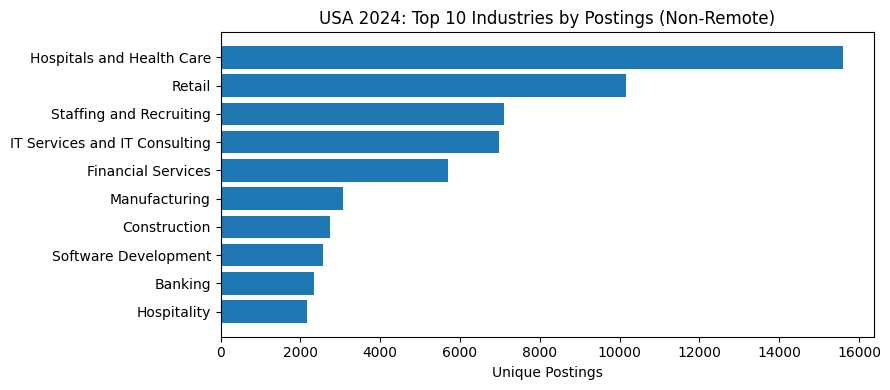

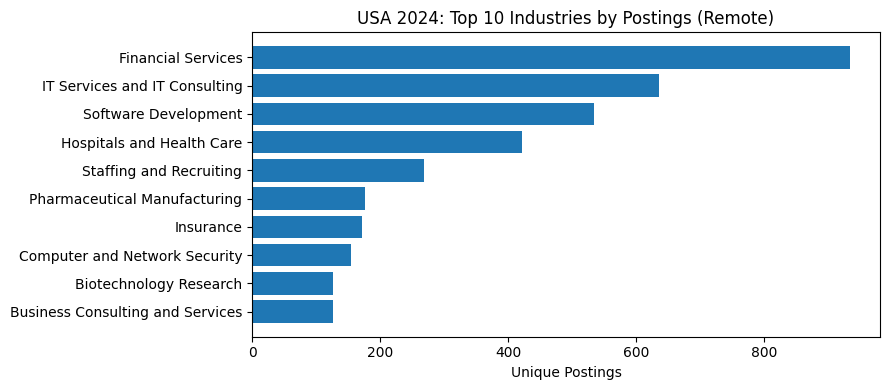

In [46]:
# --- Build job-industry dataset for USA 2024 ---
# Keep one row per job_id x industry_name to avoid duplicates
base_ind = df_merged.copy()

# detect industry name column
ind_col = None
for cand in ["industry_name","industry","industryName","name"]:
    if cand in base_ind.columns:
        ind_col = cand
        break
if ind_col is None:
    raise ValueError("Cannot find industry name column in df_merged")

ji = base_ind[["job_id", ind_col]].dropna().drop_duplicates().rename(columns={ind_col:"industry_name"})

# Join USA 2024 job metrics (job-level)
cols_need = ["job_id","is_remote","views","applies"]
for c in cols_need:
    if c not in df_2024_usa.columns:
        raise ValueError(f"Missing column in df_2024_usa: {c}")

ji = ji.merge(df_2024_usa[cols_need], on="job_id", how="inner")

# Weight to reduce over-counting for jobs with multiple industries
n_ind = ji.groupby("job_id")["industry_name"].transform("nunique").replace(0, np.nan)
ji["w"] = 1 / n_ind
ji["views_w"] = ji["views"] * ji["w"]
ji["applies_w"] = ji["applies"] * ji["w"]

agg = (ji.groupby(["is_remote","industry_name"])
       .agg(
           postings=("job_id","nunique"),
           views=("views_w","sum"),
           applies=("applies_w","sum")
       )
       .reset_index())

def top10(metric: str, is_remote: bool):
    d = agg[agg["is_remote"] == is_remote].sort_values(metric, ascending=False).head(10).copy()
    d["group"] = "Remote" if is_remote else "Non-Remote"
    return d[["group","industry_name","postings","views","applies"]]

top_posts_remote = top10("postings", True)
top_posts_non    = top10("postings", False)
top_views_remote = top10("views", True)
top_views_non    = top10("views", False)
top_apps_remote  = top10("applies", True)
top_apps_non     = top10("applies", False)

print("Top 10 industries by POSTINGS (USA 2024)")
display(pd.concat([top_posts_remote, top_posts_non], ignore_index=True))

print("Top 10 industries by VIEWS (USA 2024)  *views are weighted to reduce multi-industry double count*")
display(pd.concat([top_views_remote, top_views_non], ignore_index=True))

print("Top 10 industries by APPLIES (USA 2024) *applies are weighted to reduce multi-industry double count*")
display(pd.concat([top_apps_remote, top_apps_non], ignore_index=True))

# Simple bar charts (Top 10 postings)
def barh_top(d, title):
    plt.figure(figsize=(9,4))
    plt.barh(d["industry_name"][::-1], d["postings"][::-1])
    plt.title(title)
    plt.xlabel("Unique Postings")
    plt.tight_layout()
    plt.show()

barh_top(top_posts_non, "USA 2024: Top 10 Industries by Postings (Non-Remote)")
barh_top(top_posts_remote, "USA 2024: Top 10 Industries by Postings (Remote)")

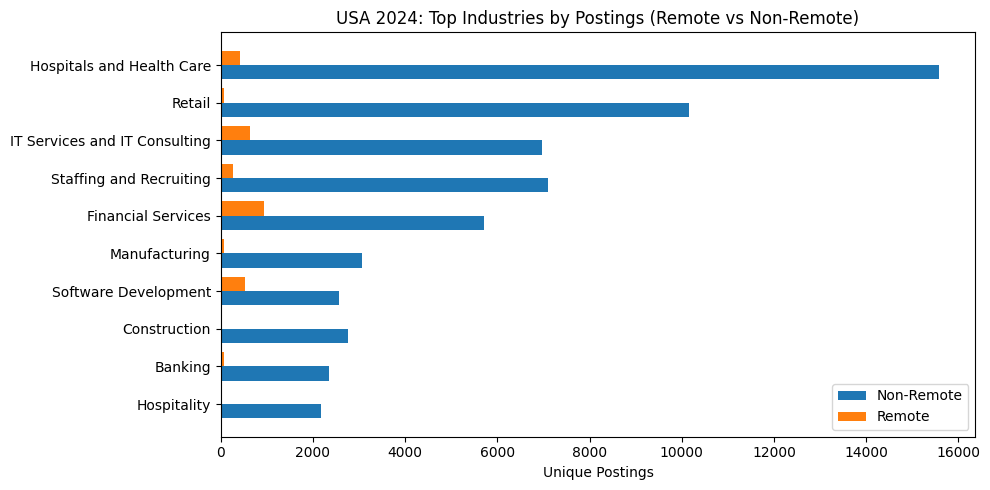

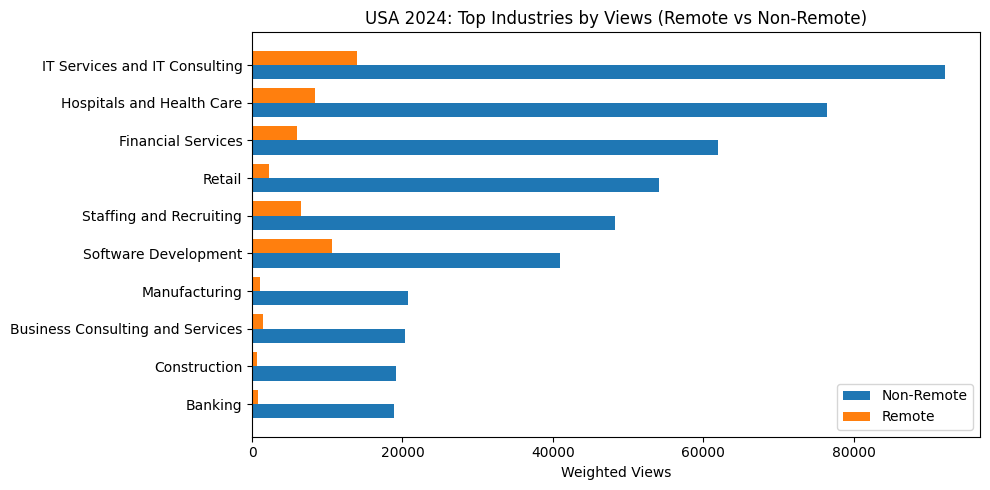

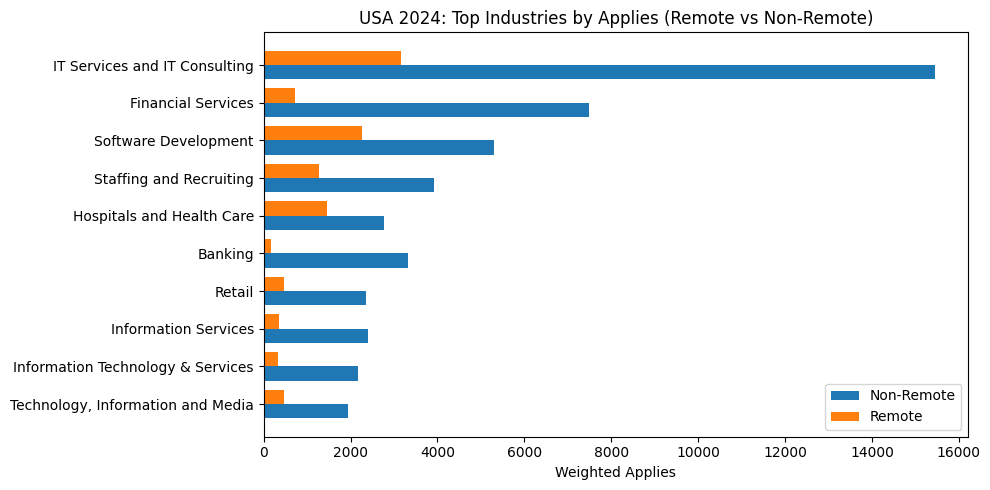

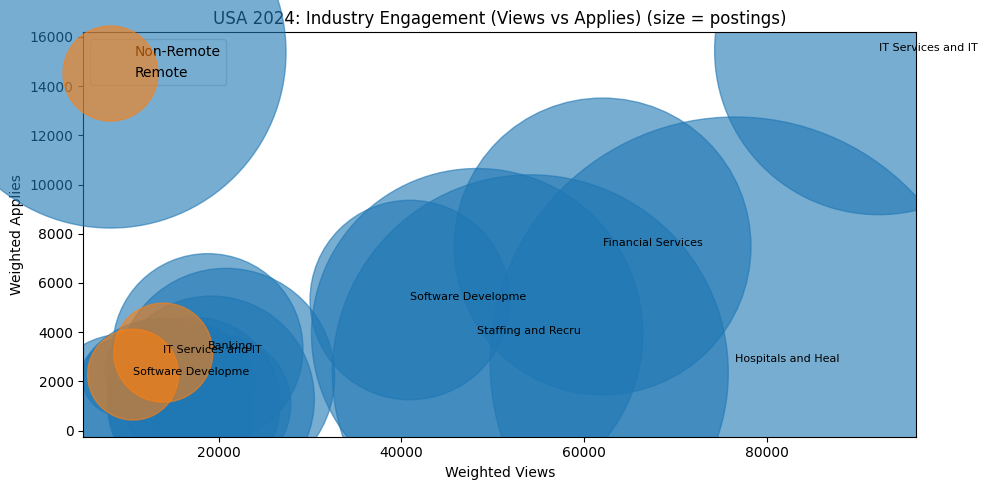

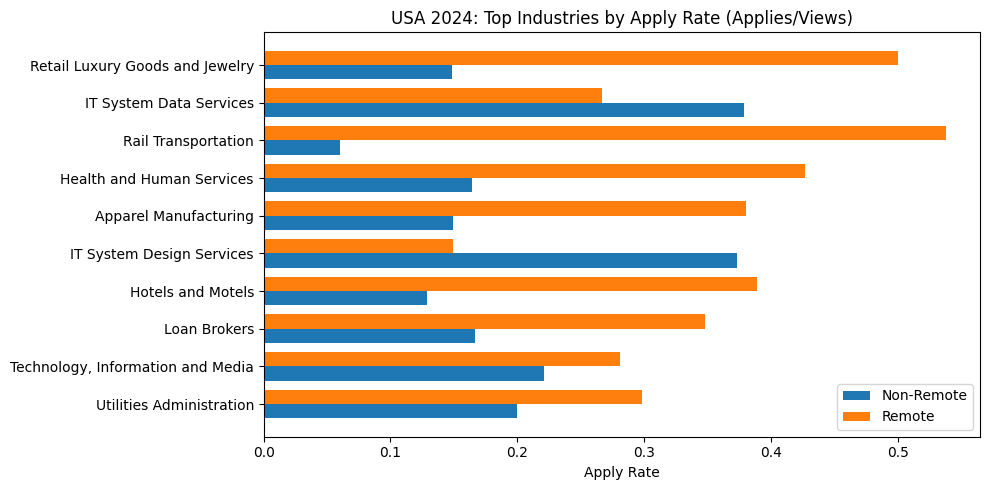

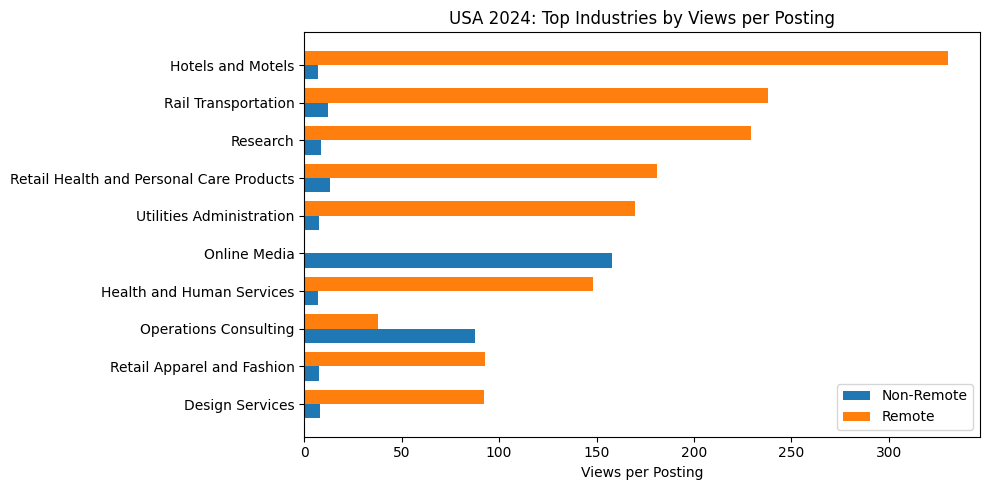

In [47]:
# =========================
# Visualization Pack: Postings / Views / Applies (USA 2024)
# ใช้จาก agg ที่คำนวณไว้แล้ว (weighted views/applies แล้ว)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) Prep: เพิ่มชื่อกลุ่ม + metrics เพิ่มเติม ----------
viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# กันหารศูนย์
viz["apply_rate"] = np.where(viz["views"] > 0, viz["applies"] / viz["views"], 0.0)          # สมัคร/คนดู
viz["views_per_posting"] = np.where(viz["postings"] > 0, viz["views"] / viz["postings"], 0.0)
viz["applies_per_posting"] = np.where(viz["postings"] > 0, viz["applies"] / viz["postings"], 0.0)

# helper: top10 by metric for each group
def top10_by(metric, group_name):
    d = viz[viz["group"] == group_name].sort_values(metric, ascending=False).head(10).copy()
    return d

# =========================
# 1) Grouped Bar: Top 10 industries (Remote vs Non-Remote)
# =========================
def grouped_bar_top10(metric, title, xlabel, topn=10):
    # เลือก top จาก "รวมสองกลุ่ม" เพื่อให้แกนเดียวกันเทียบกันได้
    top_union = (viz.groupby("industry_name")[metric].sum()
                 .sort_values(ascending=False).head(topn).index)
    d = viz[viz["industry_name"].isin(top_union)].copy()

    # pivot -> Remote/Non-Remote เป็นคอลัมน์
    p = (d.pivot_table(index="industry_name", columns="group", values=metric, aggfunc="sum")
           .fillna(0))

    # จัดเรียงตามผลรวม
    p["__total__"] = p.sum(axis=1)
    p = p.sort_values("__total__", ascending=True).drop(columns="__total__")

    # plot
    plt.figure(figsize=(10, 5))
    y = np.arange(len(p.index))
    h = 0.38

    # ถ้าไม่มีคอลัมน์ใด (กันกรณีข้อมูลขาด)
    if "Non-Remote" in p.columns:
        plt.barh(y - h/2, p["Non-Remote"].values, height=h, label="Non-Remote")
    if "Remote" in p.columns:
        plt.barh(y + h/2, p["Remote"].values, height=h, label="Remote")

    plt.yticks(y, p.index)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

grouped_bar_top10("postings", "USA 2024: Top Industries by Postings (Remote vs Non-Remote)", "Unique Postings")
grouped_bar_top10("views",    "USA 2024: Top Industries by Views (Remote vs Non-Remote)",    "Weighted Views")
grouped_bar_top10("applies",  "USA 2024: Top Industries by Applies (Remote vs Non-Remote)",  "Weighted Applies")

# =========================
# 2) Bubble Scatter: Views vs Applies (size=Postings, color=Remote/Non-Remote)
# =========================
def bubble_scatter(title, topn_each=12):
    # เลือก industry เด่น ๆ จากทั้งสองฝั่ง เพื่อให้กราฟไม่แน่นเกิน
    d1 = viz.sort_values("views", ascending=False).head(topn_each)
    d2 = viz.sort_values("applies", ascending=False).head(topn_each)
    d3 = viz.sort_values("postings", ascending=False).head(topn_each)
    d = pd.concat([d1, d2, d3], ignore_index=True).drop_duplicates(["group","industry_name"])

    plt.figure(figsize=(10, 5))
    for g in ["Non-Remote", "Remote"]:
        dg = d[d["group"] == g]
        if dg.empty:
            continue
        # ขนาด bubble: postings (ปรับสเกลให้ดูพอดี)
        s = (dg["postings"].values + 1) * 8
        plt.scatter(dg["views"], dg["applies"], s=s, alpha=0.6, label=g)

        # ใส่ label industry แบบเลือกเฉพาะบางจุดเพื่อไม่ให้รก
        for _, r in dg.sort_values("applies", ascending=False).head(6).iterrows():
            plt.text(r["views"], r["applies"], r["industry_name"][:18], fontsize=8)

    plt.xlabel("Weighted Views")
    plt.ylabel("Weighted Applies")
    plt.title(title + " (size = postings)")
    plt.legend()
    plt.tight_layout()
    plt.show()

bubble_scatter("USA 2024: Industry Engagement (Views vs Applies)")

# =========================
# 3) Efficiency View: Apply Rate & Views/Postings (Top 10)
# =========================
grouped_bar_top10("apply_rate",        "USA 2024: Top Industries by Apply Rate (Applies/Views)", "Apply Rate", topn=10)
grouped_bar_top10("views_per_posting", "USA 2024: Top Industries by Views per Posting",          "Views per Posting", topn=10)

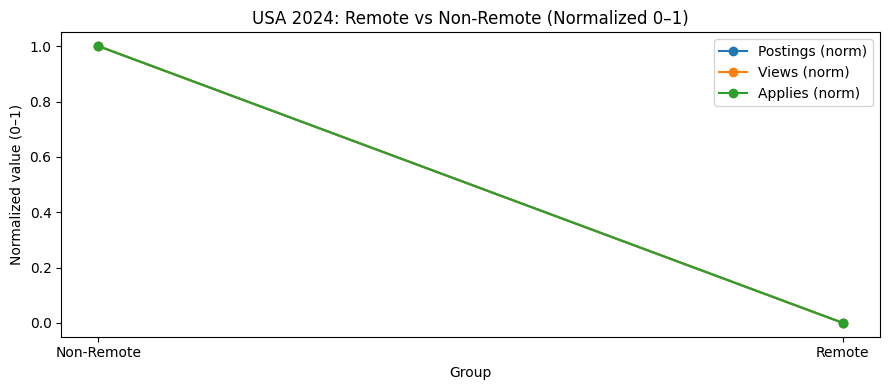

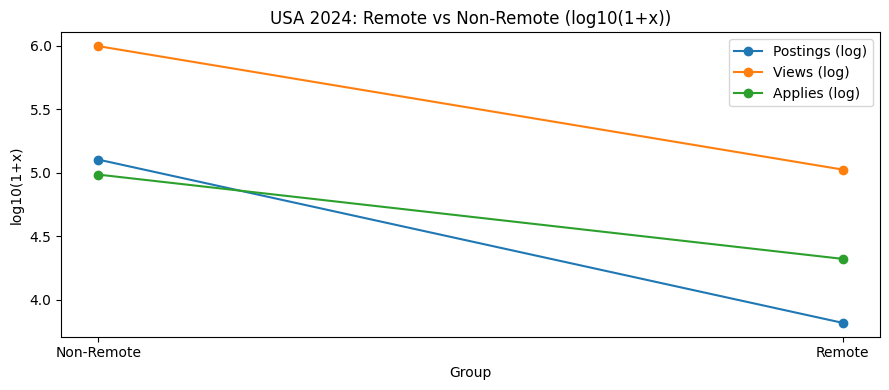

,group,postings,views,applies
0,Non-Remote,126638,992076.0,96496.0
1,Remote,6551,105687.0,20922.0


In [48]:
# =========================
# Line Charts: Postings / Views / Applies (Remote vs Non-Remote)
# - เหมาะเมื่อสัดส่วนต่างกันมาก
# - มี 2 โหมด: normalize (0–1) และ log10(1+x)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# --- รวมเป็นระดับ group (รวมทุก industry) เพื่อทำเส้น 2 เส้นเปรียบเทียบ ---
g = (viz.groupby("group")[["postings","views","applies"]]
     .sum()
     .reset_index())

# --- helper: normalize 0-1 ภายในแต่ละ metric ---
def minmax(s):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return s * 0
    return (s - mn) / (mx - mn)

g_norm = g.copy()
for c in ["postings","views","applies"]:
    g_norm[c] = minmax(g_norm[c])

g_log = g.copy()
for c in ["postings","views","applies"]:
    g_log[c] = np.log10(g_log[c].astype(float) + 1)

# =========================
# 1) Normalize line chart (0–1)
# =========================
plt.figure(figsize=(9,4))
x = g_norm["group"]

plt.plot(x, g_norm["postings"], marker="o", label="Postings (norm)")
plt.plot(x, g_norm["views"],    marker="o", label="Views (norm)")
plt.plot(x, g_norm["applies"],  marker="o", label="Applies (norm)")

plt.title("USA 2024: Remote vs Non-Remote (Normalized 0–1)")
plt.ylabel("Normalized value (0–1)")
plt.xlabel("Group")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 2) Log line chart (log10(1+x)) — ถ้าอยากเห็นค่าจริงแบบบีบสเกล
# =========================
plt.figure(figsize=(9,4))
x = g_log["group"]

plt.plot(x, g_log["postings"], marker="o", label="Postings (log)")
plt.plot(x, g_log["views"],    marker="o", label="Views (log)")
plt.plot(x, g_log["applies"],  marker="o", label="Applies (log)")

plt.title("USA 2024: Remote vs Non-Remote (log10(1+x))")
plt.ylabel("log10(1+x)")
plt.xlabel("Group")
plt.legend()
plt.tight_layout()
plt.show()

# แสดงตัวเลขจริงประกอบ (อ่านง่าย)
display(g)

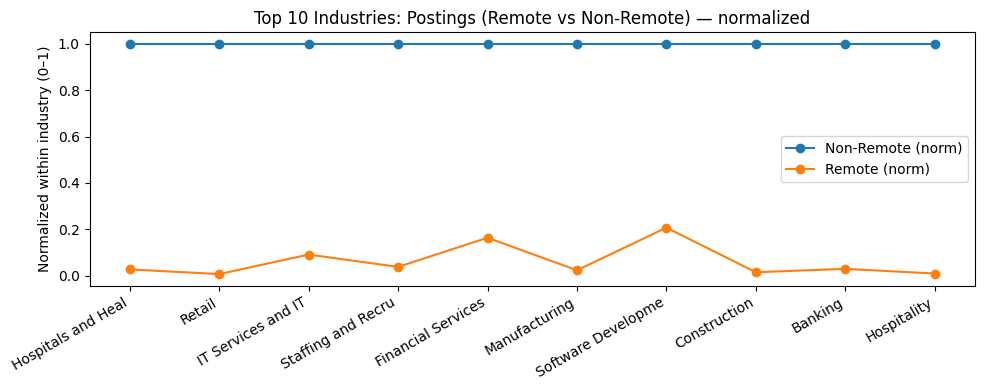

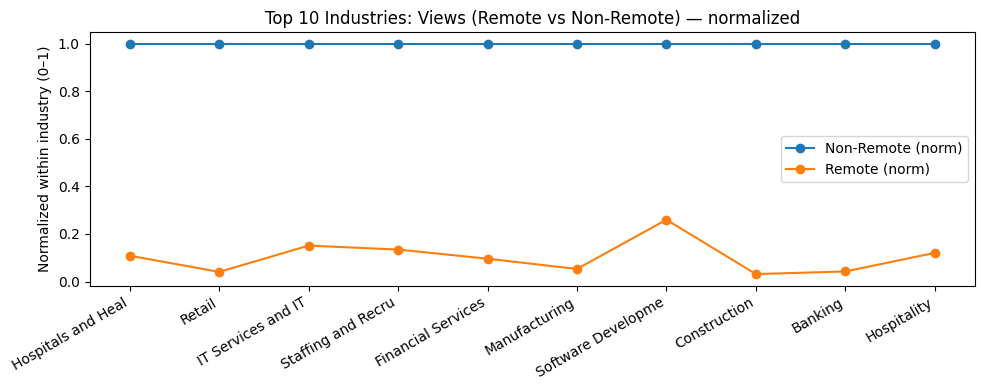

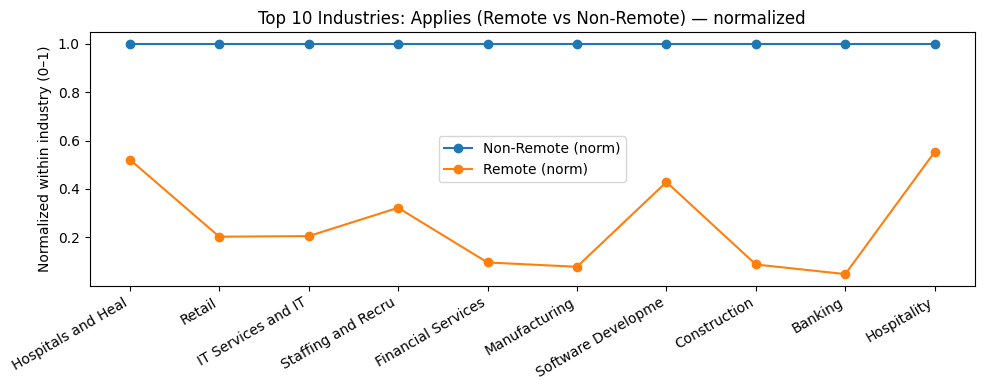

In [49]:
# =========================
# Line chart: Top 10 industries (ตาม postings รวม) แล้วเทียบ Remote vs Non-Remote
# ใช้ normalize เพื่อให้สเกลไม่กลบกัน
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# เลือก Top 10 industries จาก postings รวมสองกลุ่ม
top_ind = (viz.groupby("industry_name")["postings"].sum()
           .sort_values(ascending=False).head(10).index)

d = viz[viz["industry_name"].isin(top_ind)].copy()

# pivot ให้ได้ index=industry, columns=group
p_post = d.pivot_table(index="industry_name", columns="group", values="postings", aggfunc="sum").fillna(0)
p_view = d.pivot_table(index="industry_name", columns="group", values="views",    aggfunc="sum").fillna(0)
p_app  = d.pivot_table(index="industry_name", columns="group", values="applies",  aggfunc="sum").fillna(0)

# เรียงแกน X ตาม postings รวม
order = p_post.sum(axis=1).sort_values(ascending=False).index
p_post, p_view, p_app = p_post.loc[order], p_view.loc[order], p_app.loc[order]

def normalize_rows(p):
    # normalize ต่อ industry (แถว) เพื่อเทียบ Remote vs Non-Remote ในแต่ละ industry
    out = p.copy().astype(float)
    rowmax = out.max(axis=1).replace(0, np.nan)
    return out.div(rowmax, axis=0).fillna(0)

p_post_n = normalize_rows(p_post)
p_view_n = normalize_rows(p_view)
p_app_n  = normalize_rows(p_app)

x = np.arange(len(order))

def plot_two_lines(pn, title):
    plt.figure(figsize=(10,4))
    if "Non-Remote" in pn.columns:
        plt.plot(x, pn["Non-Remote"].values, marker="o", label="Non-Remote (norm)")
    if "Remote" in pn.columns:
        plt.plot(x, pn["Remote"].values, marker="o", label="Remote (norm)")
    plt.xticks(x, [s[:18] for s in order], rotation=30, ha="right")
    plt.ylabel("Normalized within industry (0–1)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_two_lines(p_post_n, "Top 10 Industries: Postings (Remote vs Non-Remote) — normalized")
plot_two_lines(p_view_n, "Top 10 Industries: Views (Remote vs Non-Remote) — normalized")
plot_two_lines(p_app_n,  "Top 10 Industries: Applies (Remote vs Non-Remote) — normalized")

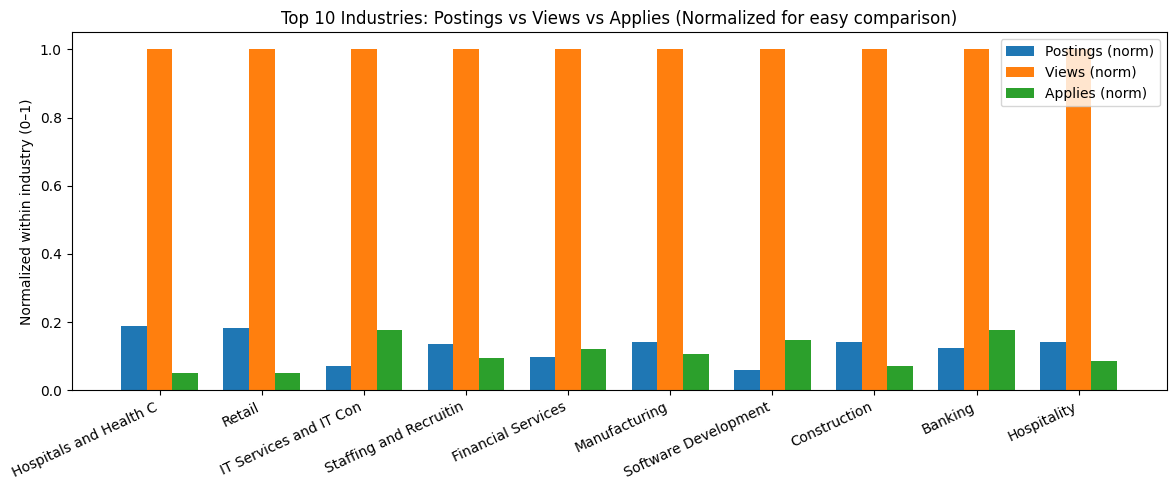

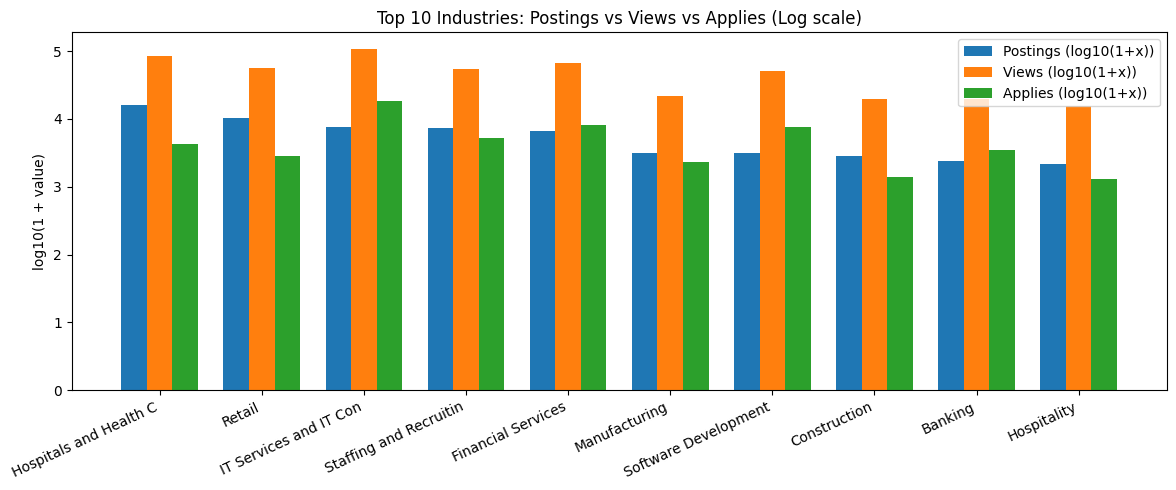

,industry_name,postings,views,applies
147,Hospitals and Health Care,16008,84844.500000,4230.333333
282,Retail,10230,56286.333333,2826.666667
155,IT Services and IT Consulting,7603,106148.000000,18611.833333
322,Staffing and Recruiting,7379,54770.166667,5184.500000
114,Financial Services,6641,67963.500000,8205.500000
194,Manufacturing,3128,21900.666667,2352.000000
313,Software Development,3111,51549.666667,7583.833333
68,Construction,2795,19795.333333,1388.166667
30,Banking,2415,19613.000000,3484.500000
145,Hospitality,2190,15397.500000,1301.833333


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1) สรุปต่อ industry_name (รวม Remote+Non-Remote) =====
ind = (agg.groupby("industry_name")[["postings","views","applies"]]
       .sum()
       .reset_index())

# เลือก Top N industries ตาม postings (ปรับได้)
TOP_N = 10
ind = ind.sort_values("postings", ascending=False).head(TOP_N).copy()

# เพื่อให้ label ไม่ยาวเกินไป (ตัดได้ตามต้องการ)
ind["industry_short"] = ind["industry_name"].str.slice(0, 22)

# ===== 2) ทำ normalize 0–1 ภายในแต่ละ industry (เทียบง่ายสุด) =====
vals = ind[["postings","views","applies"]].astype(float).values
row_max = np.max(vals, axis=1).reshape(-1, 1)
row_max[row_max == 0] = 1
norm = vals / row_max

ind_norm = ind.copy()
ind_norm[["postings","views","applies"]] = norm  # replace with normalized

# ===== Plot A: Normalized grouped bar =====
x = np.arange(len(ind_norm))
w = 0.25

plt.figure(figsize=(12,5))
plt.bar(x - w, ind_norm["postings"], width=w, label="Postings (norm)")
plt.bar(x,      ind_norm["views"],   width=w, label="Views (norm)")
plt.bar(x + w,  ind_norm["applies"], width=w, label="Applies (norm)")

plt.xticks(x, ind_norm["industry_short"], rotation=25, ha="right")
plt.ylabel("Normalized within industry (0–1)")
plt.title(f"Top {TOP_N} Industries: Postings vs Views vs Applies (Normalized for easy comparison)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== 3) Plot B: Log scale grouped bar (เห็นค่าจริงแบบบีบสเกล) =====
ind_log = ind.copy()
for c in ["postings","views","applies"]:
    ind_log[c] = np.log10(ind_log[c].astype(float) + 1)

x = np.arange(len(ind_log))

plt.figure(figsize=(12,5))
plt.bar(x - w, ind_log["postings"], width=w, label="Postings (log10(1+x))")
plt.bar(x,      ind_log["views"],   width=w, label="Views (log10(1+x))")
plt.bar(x + w,  ind_log["applies"], width=w, label="Applies (log10(1+x))")

plt.xticks(x, ind_log["industry_short"], rotation=25, ha="right")
plt.ylabel("log10(1 + value)")
plt.title(f"Top {TOP_N} Industries: Postings vs Views vs Applies (Log scale)")
plt.legend()
plt.tight_layout()
plt.show()

# (optional) แสดงตารางค่าจริงให้ดูประกอบ
display(ind[["industry_name","postings","views","applies"]])

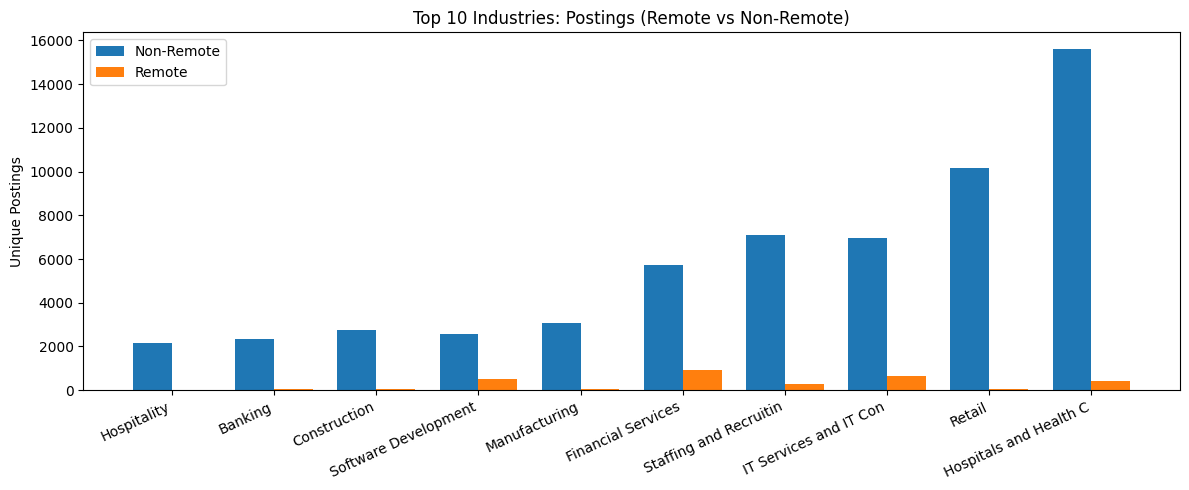

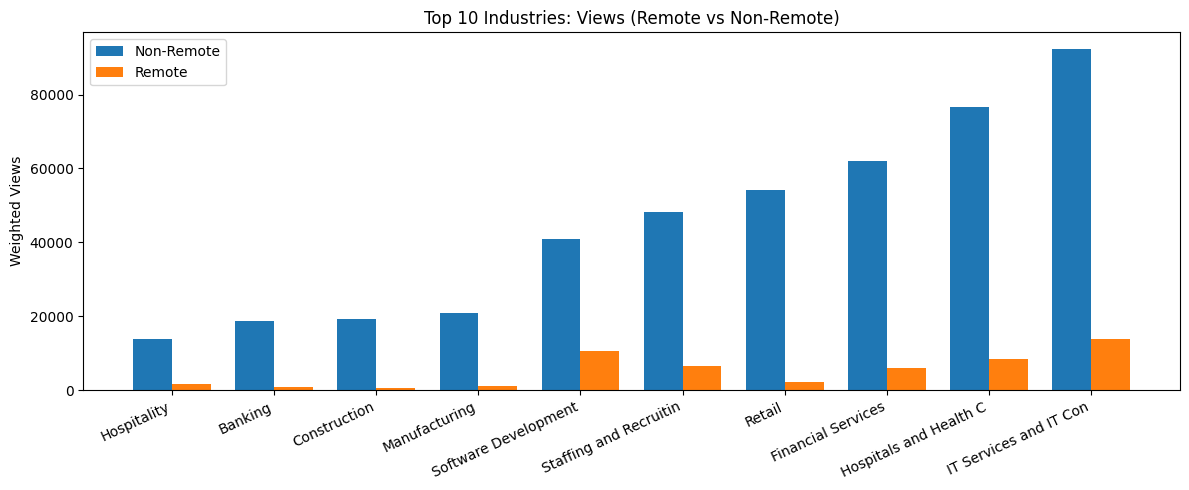

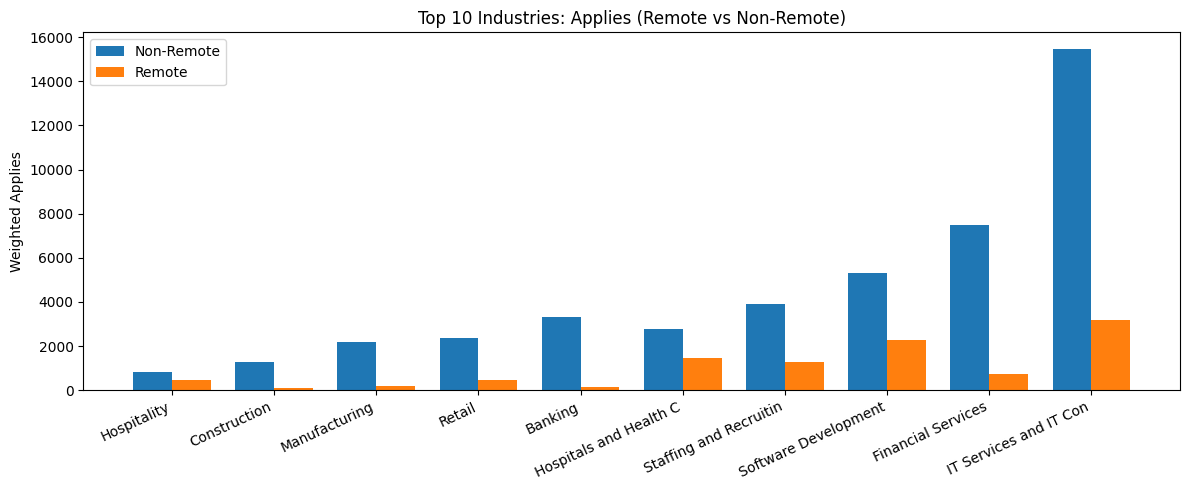

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 3 Separate Charts: Postings / Views / Applies
# Compare Remote vs Non-Remote per industry
# =========================

TOP_N = 10          # ปรับได้
LABEL_MAX = 22      # ตัดชื่อ industry กันยาว

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# เลือก Top industries จาก postings "รวมสองกลุ่ม" เพื่อให้แกนเดียวกัน
top_ind = (viz.groupby("industry_name")["postings"].sum()
           .sort_values(ascending=False).head(TOP_N).index)

d = viz[viz["industry_name"].isin(top_ind)].copy()

# pivot -> index industry, columns group
def make_pivot(metric):
    p = (d.pivot_table(index="industry_name", columns="group", values=metric, aggfunc="sum")
           .fillna(0))
    # เรียงตามรวม (ให้ดูง่าย)
    p["__total__"] = p.sum(axis=1)
    p = p.sort_values("__total__", ascending=True).drop(columns="__total__")
    return p

def plot_grouped_bar(p, title, ylabel):
    x = np.arange(len(p.index))
    w = 0.38

    plt.figure(figsize=(12,5))
    if "Non-Remote" in p.columns:
        plt.bar(x - w/2, p["Non-Remote"].values, width=w, label="Non-Remote")
    if "Remote" in p.columns:
        plt.bar(x + w/2, p["Remote"].values, width=w, label="Remote")

    labels = [s[:LABEL_MAX] for s in p.index]
    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 1) Postings
p_post = make_pivot("postings")
plot_grouped_bar(p_post, f"Top {TOP_N} Industries: Postings (Remote vs Non-Remote)", "Unique Postings")

# 2) Views (weighted)
p_view = make_pivot("views")
plot_grouped_bar(p_view, f"Top {TOP_N} Industries: Views (Remote vs Non-Remote)", "Weighted Views")

# 3) Applies (weighted)
p_app = make_pivot("applies")
plot_grouped_bar(p_app, f"Top {TOP_N} Industries: Applies (Remote vs Non-Remote)", "Weighted Applies")

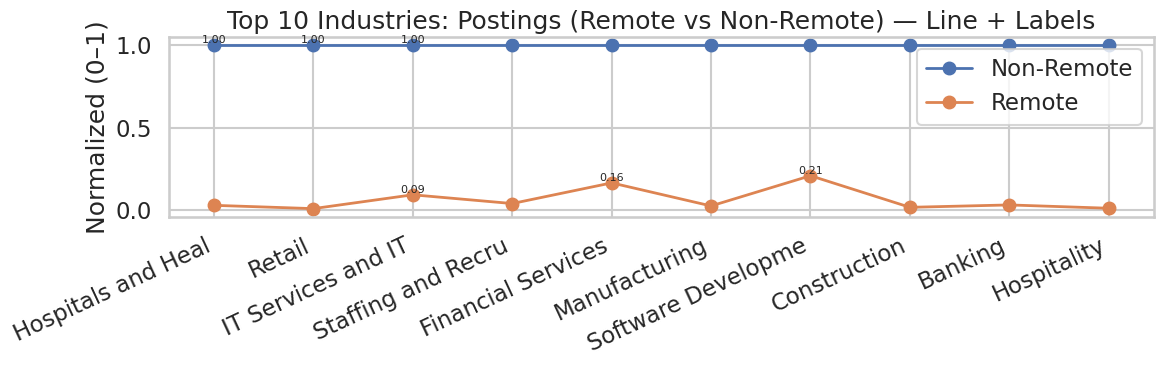

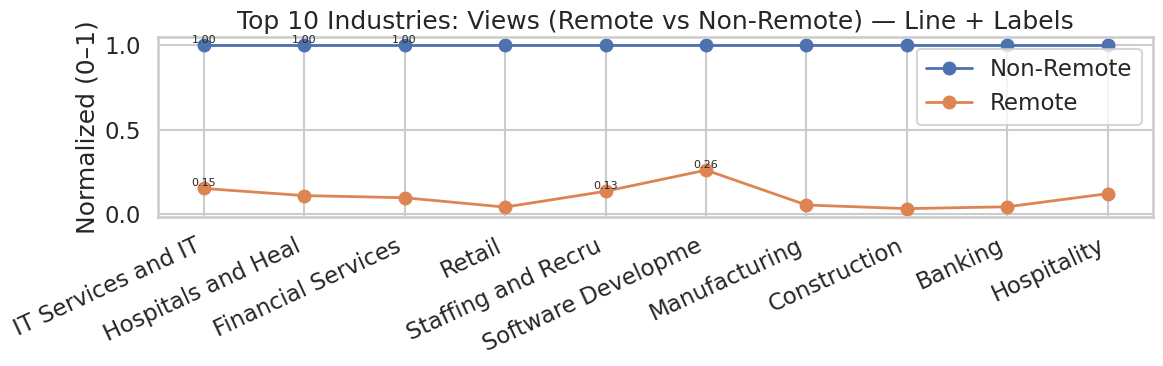

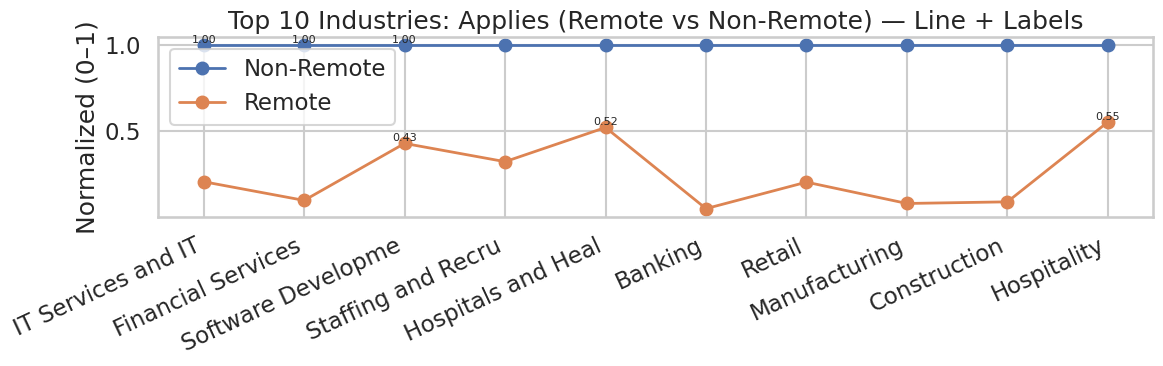

In [66]:
# =========================
# Line chart with markers + data labels (เหมือนรูปตัวอย่าง)
# เปรียบเทียบ Remote vs Non-Remote ต่อ metric ที่เลือก
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 10
LABEL_MAX = 18

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# เลือก Top industries จาก postings รวม
top_ind = (viz.groupby("industry_name")["postings"].sum()
           .sort_values(ascending=False).head(TOP_N).index)

d = viz[viz["industry_name"].isin(top_ind)].copy()

# pivot ตาม metric
def pivot_metric(metric):
    p = (d.pivot_table(index="industry_name", columns="group", values=metric, aggfunc="sum")
           .fillna(0))
    # เรียงตามรวม
    p["__total__"] = p.sum(axis=1)
    p = p.sort_values("__total__", ascending=False).drop(columns="__total__")
    return p

# normalize ต่อ industry เพื่อเทียบ Remote vs Non-Remote ในแต่ละ industry (0-1)
def normalize_rows(p):
    out = p.astype(float).copy()
    m = out.max(axis=1).replace(0, np.nan)
    return out.div(m, axis=0).fillna(0)

def line_with_labels(pn, title, ylabel="Normalized (0–1)", label_points=3):
    x = np.arange(len(pn.index))
    plt.figure(figsize=(12,4))

    for g in ["Non-Remote","Remote"]:
        if g not in pn.columns:
            continue
        y = pn[g].values
        plt.plot(x, y, marker="o", linewidth=2, label=g)

        # ใส่ตัวเลขบนจุด เฉพาะ top จุด (กันรก)
        top_idx = np.argsort(-y)[:label_points]
        for i in top_idx:
            plt.text(x[i], y[i], f"{y[i]:.2f}", fontsize=8, ha="center", va="bottom")

    plt.xticks(x, [s[:LABEL_MAX] for s in pn.index], rotation=25, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# เลือก metric ที่อยากทำเส้น
for metric, t in [("postings","Postings"), ("views","Views"), ("applies","Applies")]:
    p = pivot_metric(metric)
    pn = normalize_rows(p)
    line_with_labels(pn, f"Top {TOP_N} Industries: {t} (Remote vs Non-Remote) — Line + Labels", label_points=3)

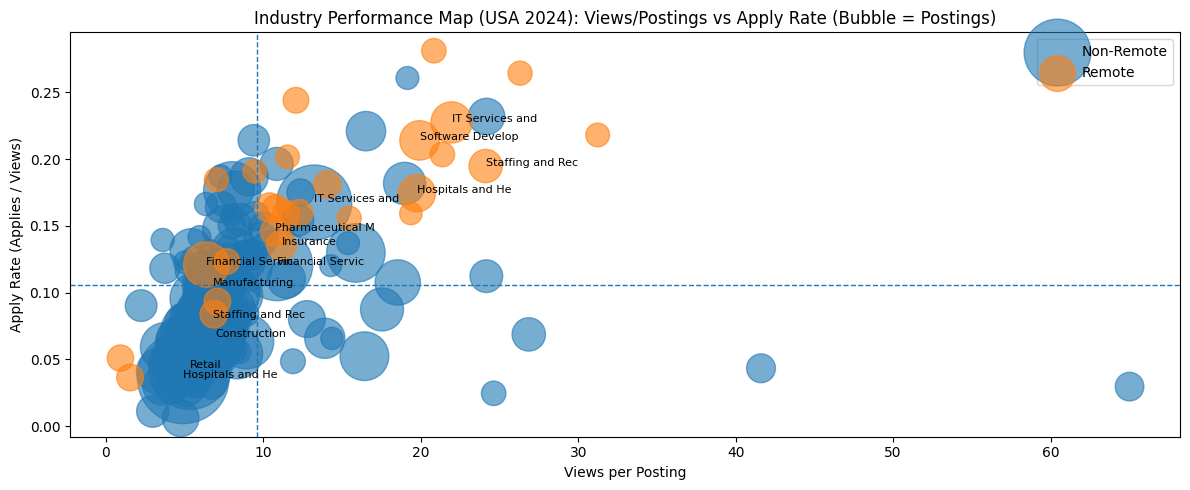

In [53]:
# =========================
# Bubble Scatter + Mean lines (Quadrants) + Labels (เหมือนรูปตัวอย่าง)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# เพิ่ม metrics แบบอ่านง่าย
viz["apply_rate"] = np.where(viz["views"] > 0, viz["applies"] / viz["views"], 0.0)
viz["views_per_posting"] = np.where(viz["postings"] > 0, viz["views"] / viz["postings"], 0.0)

# เลือกเฉพาะ industry ที่มี postings พอ (กัน noise)
MIN_POSTINGS = 50
d = viz[viz["postings"] >= MIN_POSTINGS].copy()

# ค่าเฉลี่ยรวม (ใช้แบ่ง quadrant)
x_mean = d["views_per_posting"].mean()
y_mean = d["apply_rate"].mean()

plt.figure(figsize=(12,5))

for g in ["Non-Remote","Remote"]:
    dg = d[d["group"] == g]
    if dg.empty:
        continue

    # bubble size สเกล
    s = (dg["postings"].values ** 0.5) * 35  # sqrt ช่วยไม่ให้ต่างกันโหด
    plt.scatter(dg["views_per_posting"], dg["apply_rate"], s=s, alpha=0.6, label=g)

    # ใส่ label เฉพาะจุดเด่น (เลือก top by postings)
    for _, r in dg.sort_values("postings", ascending=False).head(7).iterrows():
        plt.text(r["views_per_posting"], r["apply_rate"], r["industry_name"][:16], fontsize=8)

# เส้น mean (quadrants)
plt.axvline(x_mean, linestyle="--", linewidth=1)
plt.axhline(y_mean, linestyle="--", linewidth=1)

plt.title("Industry Performance Map (USA 2024): Views/Postings vs Apply Rate (Bubble = Postings)")
plt.xlabel("Views per Posting")
plt.ylabel("Apply Rate (Applies / Views)")
plt.legend()
plt.tight_layout()
plt.show()

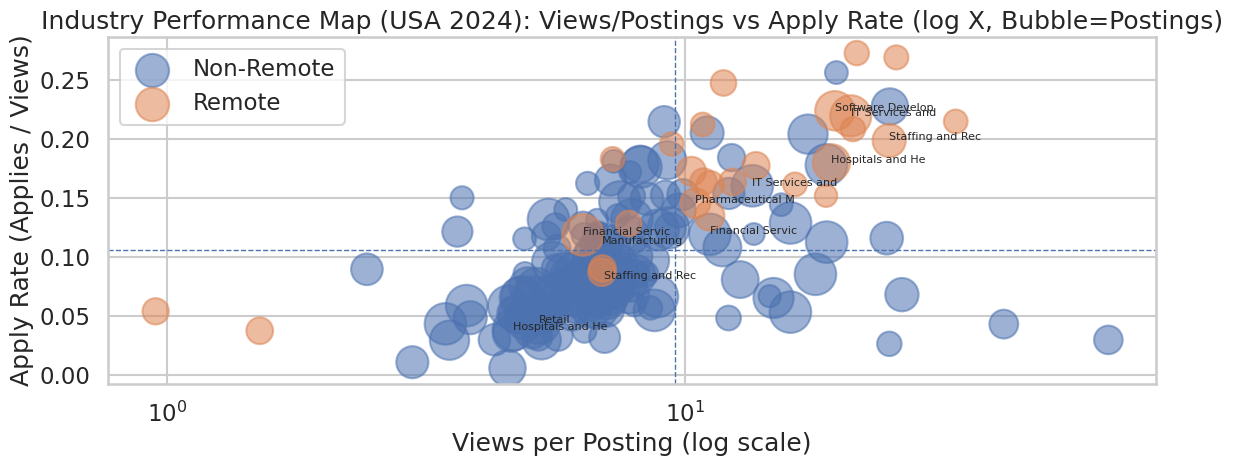

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

viz["apply_rate"] = np.where(viz["views"] > 0, viz["applies"] / viz["views"], 0.0)
viz["views_per_posting"] = np.where(viz["postings"] > 0, viz["views"] / viz["postings"], 0.0)

MIN_POSTINGS = 50
d = viz[viz["postings"] >= MIN_POSTINGS].copy()

# (optional) jitter เล็กน้อยกันทับกัน
rng = np.random.default_rng(42)
d["x_jit"] = d["views_per_posting"] * (1 + rng.normal(0, 0.03, len(d)))  # +-3%
d["y_jit"] = d["apply_rate"] * (1 + rng.normal(0, 0.03, len(d)))

# ค่าเฉลี่ย (ใช้ค่าจริง ไม่ใช่ jit)
x_mean = d["views_per_posting"].mean()
y_mean = d["apply_rate"].mean()

plt.figure(figsize=(12,5))

for g in ["Non-Remote","Remote"]:
    dg = d[d["group"] == g]
    if dg.empty:
        continue

    # bubble size: ลดความต่างด้วย sqrt และคุมเพดาน
    s = np.sqrt(dg["postings"].values) * 35
    s = np.clip(s, 30, 900)

    plt.scatter(dg["x_jit"], dg["y_jit"], s=s, alpha=0.55, label=g)

    # ใส่ label เฉพาะจุดเด่น (เช่น postings สูงสุด)
    for _, r in dg.sort_values("postings", ascending=False).head(6).iterrows():
        plt.text(r["x_jit"], r["y_jit"], r["industry_name"][:16], fontsize=8)

# mean lines (ต้องวาดด้วยค่าจริง)
plt.axvline(x_mean, linestyle="--", linewidth=1)
plt.axhline(y_mean, linestyle="--", linewidth=1)

# ✅ ทำให้ไม่กระจุก: ใช้ log scale ที่แกน X
plt.xscale("log")

plt.title("Industry Performance Map (USA 2024): Views/Postings vs Apply Rate (log X, Bubble=Postings)")
plt.xlabel("Views per Posting (log scale)")
plt.ylabel("Apply Rate (Applies / Views)")
plt.legend()
plt.tight_layout()
plt.show()

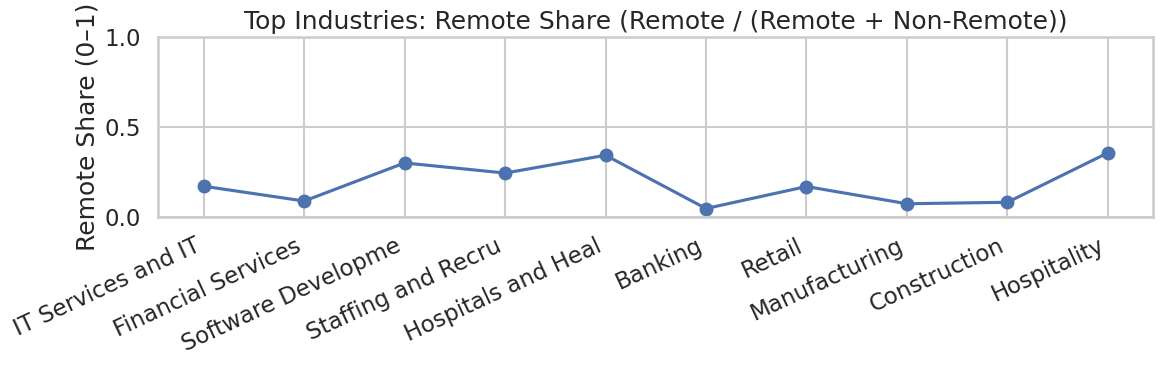

In [68]:
# p = pivot ที่มีคอลัมน์ Remote / Non-Remote
share = p["Remote"] / (p["Remote"] + p["Non-Remote"])

plt.figure(figsize=(12,4))
plt.plot(np.arange(len(share)), share.values, marker="o")
plt.xticks(np.arange(len(share)), [s[:18] for s in share.index], rotation=25, ha="right")
plt.ylim(0,1)
plt.ylabel("Remote Share (0–1)")
plt.title("Top Industries: Remote Share (Remote / (Remote + Non-Remote))")
plt.tight_layout()
plt.show()

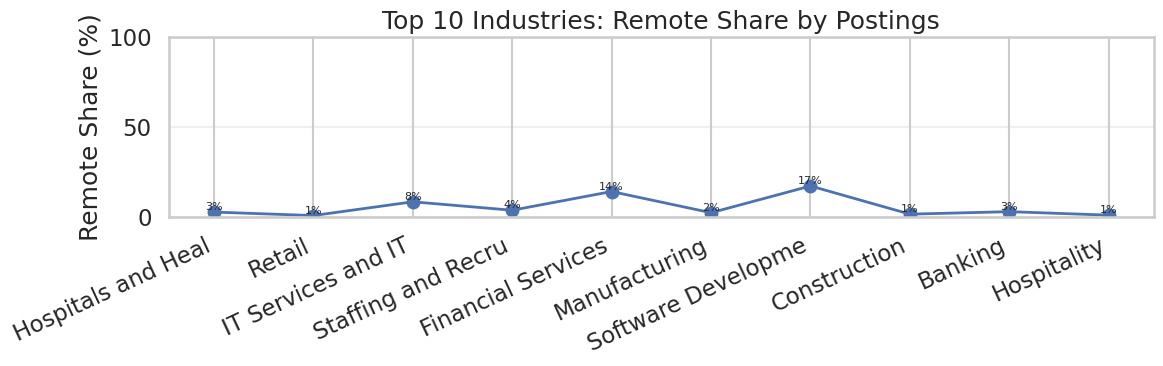

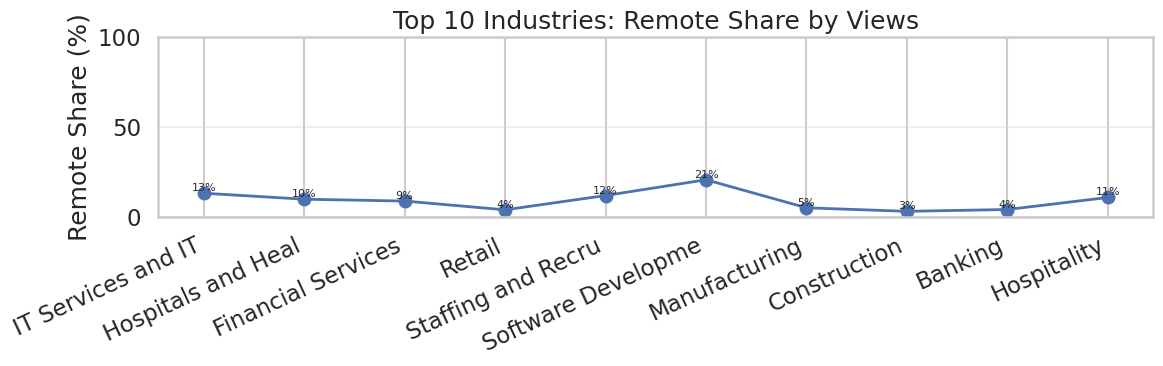

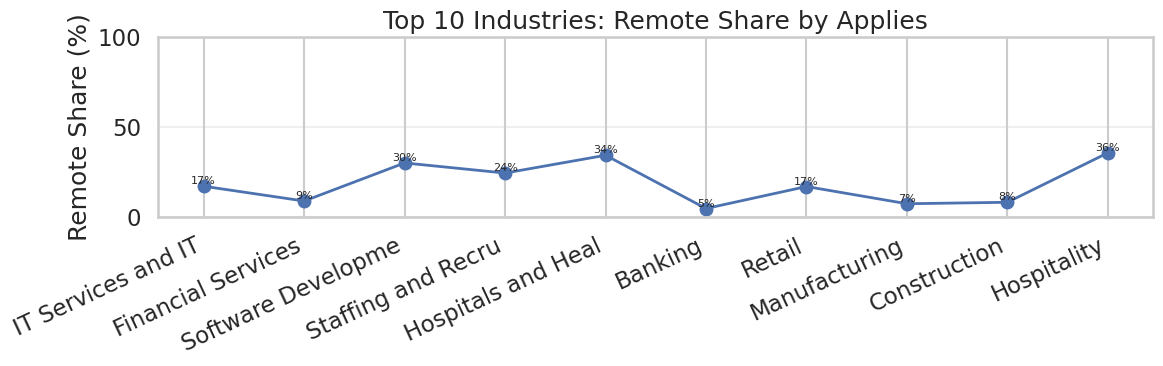

In [69]:
# =========================
# Line Chart (End-user friendly):
# Remote Share by Industry
# share = Remote / (Remote + Non-Remote)
# ทำ 3 รูป: Postings / Views / Applies
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 10
LABEL_MAX = 18

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

def make_pivot(metric):
    # เลือก Top industries ตาม postings รวมสองกลุ่ม (แกนเดียวกันทุกกราฟ)
    top_ind = (viz.groupby("industry_name")["postings"].sum()
               .sort_values(ascending=False).head(TOP_N).index)
    d = viz[viz["industry_name"].isin(top_ind)].copy()

    p = (d.pivot_table(index="industry_name", columns="group", values=metric, aggfunc="sum")
           .fillna(0))

    # ให้มีครบทั้ง 2 คอลัมน์เสมอ
    if "Remote" not in p.columns:
        p["Remote"] = 0
    if "Non-Remote" not in p.columns:
        p["Non-Remote"] = 0

    # เรียงแกน x ตาม "ขนาดรวม" ของ metric นั้น ๆ (หรือจะใช้ postings ก็ได้)
    p["__total__"] = p["Remote"] + p["Non-Remote"]
    p = p.sort_values("__total__", ascending=False).drop(columns="__total__")
    return p

def plot_remote_share(metric, title):
    p = make_pivot(metric)
    denom = (p["Remote"] + p["Non-Remote"]).replace(0, np.nan)
    share = (p["Remote"] / denom).fillna(0)

    x = np.arange(len(share))
    y = share.values * 100  # เป็น %

    plt.figure(figsize=(12,4))
    plt.plot(x, y, marker="o", linewidth=2)

    # ใส่ label เป็น % บนจุด (เลือกใส่ทุกจุดได้ เพราะมีแค่ TOP_N)
    for i, val in enumerate(y):
        plt.text(x[i], val, f"{val:.0f}%", fontsize=8, ha="center", va="bottom")

    plt.xticks(x, [s[:LABEL_MAX] for s in share.index], rotation=25, ha="right")
    plt.ylim(0, 100)
    plt.ylabel("Remote Share (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3 รูป: postings / views / applies
plot_remote_share("postings", f"Top {TOP_N} Industries: Remote Share by Postings")
plot_remote_share("views",    f"Top {TOP_N} Industries: Remote Share by Views")
plot_remote_share("applies",  f"Top {TOP_N} Industries: Remote Share by Applies")

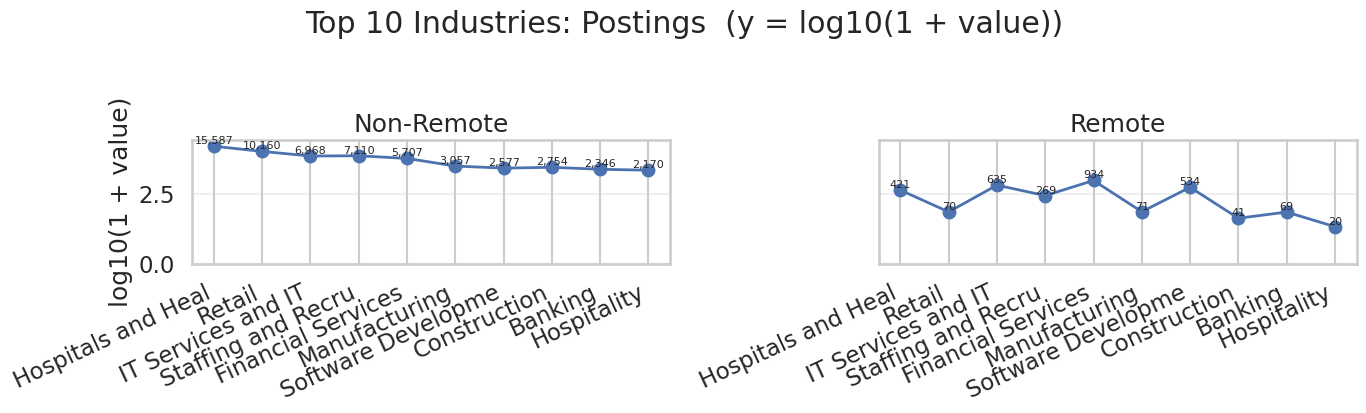

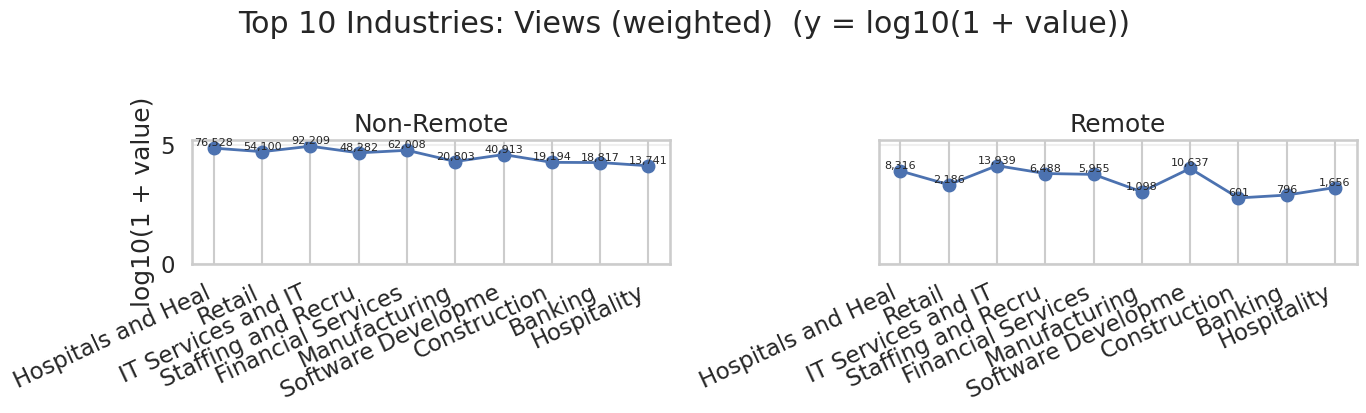

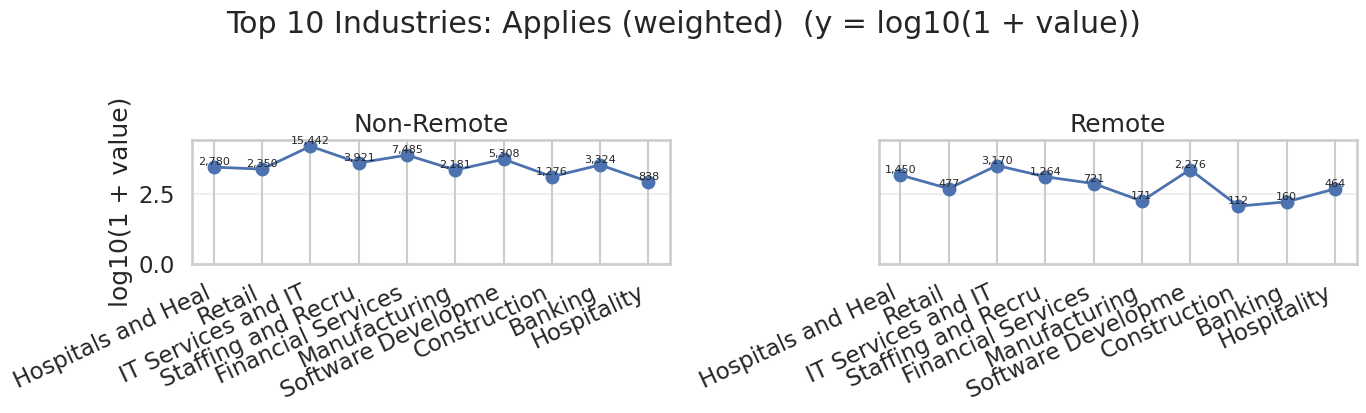

In [70]:
# =========================
# Line Charts (Side-by-side):
# Non-Remote vs Remote (separate axes, same scale)
# - x = Top N industries (same order)
# - y = log10(1 + value)  -> ช่วยแก้สเกลต่างกันมาก
# - ทำ 3 ชุด: postings / views / applies
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 10
LABEL_MAX = 18

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# เลือก Top industries ด้วย postings รวม (แกนเดียวกันทุกกราฟ)
top_ind = (viz.groupby("industry_name")["postings"].sum()
           .sort_values(ascending=False).head(TOP_N).index)

d = viz[viz["industry_name"].isin(top_ind)].copy()

def pivot_metric(metric):
    p = (d.pivot_table(index="industry_name", columns="group", values=metric, aggfunc="sum")
           .fillna(0))
    # ให้มีครบ 2 คอลัมน์
    if "Non-Remote" not in p.columns:
        p["Non-Remote"] = 0
    if "Remote" not in p.columns:
        p["Remote"] = 0

    # เรียงตาม postings รวม (เพื่อให้อ่านง่ายและสอดคล้อง)
    base_order = (d.groupby("industry_name")["postings"].sum().sort_values(ascending=False).index)
    p = p.loc[base_order]
    return p

def side_by_side_lines(metric, title):
    p = pivot_metric(metric)

    # ใช้ log scale เพื่อไม่ให้ค่ากลบกัน
    y_non = np.log10(p["Non-Remote"].astype(float) + 1)
    y_rem = np.log10(p["Remote"].astype(float) + 1)

    # สเกล y เดียวกัน
    y_max = max(y_non.max(), y_rem.max()) * 1.05

    x = np.arange(len(p.index))
    labels = [s[:LABEL_MAX] for s in p.index]

    fig, ax = plt.subplots(1, 2, figsize=(14,4), sharey=True)

    # --- Non-Remote ---
    ax[0].plot(x, y_non.values, marker="o", linewidth=2)
    ax[0].set_title("Non-Remote")
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(labels, rotation=25, ha="right")
    ax[0].set_ylim(0, y_max)
    ax[0].grid(axis="y", alpha=0.3)

    # ใส่ label (ค่าจริง) บนจุด
    for i, v in enumerate(p["Non-Remote"].values):
        ax[0].text(x[i], y_non.values[i], f"{v:,.0f}", fontsize=8, ha="center", va="bottom")

    # --- Remote ---
    ax[1].plot(x, y_rem.values, marker="o", linewidth=2)
    ax[1].set_title("Remote")
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(labels, rotation=25, ha="right")
    ax[1].set_ylim(0, y_max)
    ax[1].grid(axis="y", alpha=0.3)

    for i, v in enumerate(p["Remote"].values):
        ax[1].text(x[i], y_rem.values[i], f"{v:,.0f}", fontsize=8, ha="center", va="bottom")

    fig.suptitle(title + "  (y = log10(1 + value))", y=1.05)
    ax[0].set_ylabel("log10(1 + value)")
    plt.tight_layout()
    plt.show()

# 3 ชุด
side_by_side_lines("postings", f"Top {TOP_N} Industries: Postings")
side_by_side_lines("views",    f"Top {TOP_N} Industries: Views (weighted)")
side_by_side_lines("applies",  f"Top {TOP_N} Industries: Applies (weighted)")

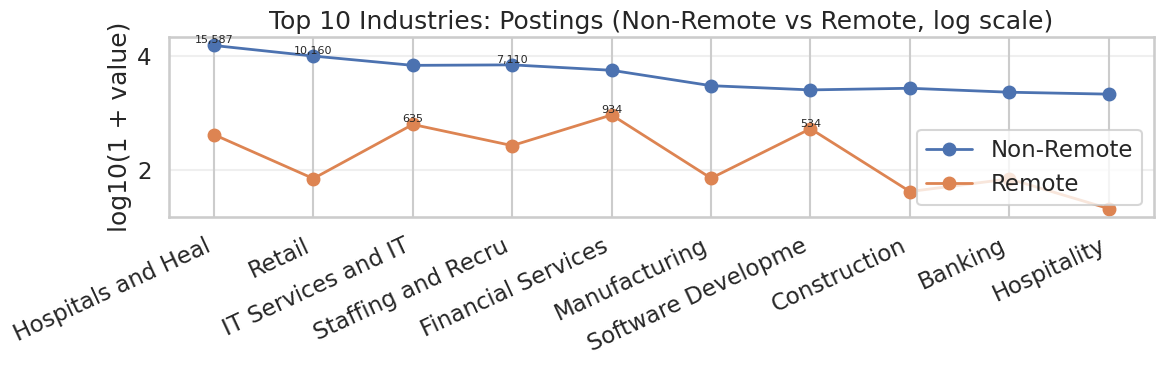

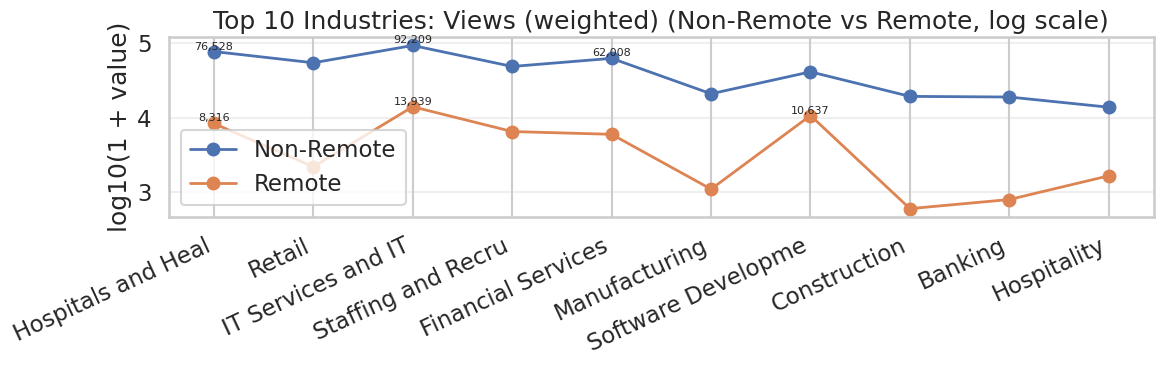

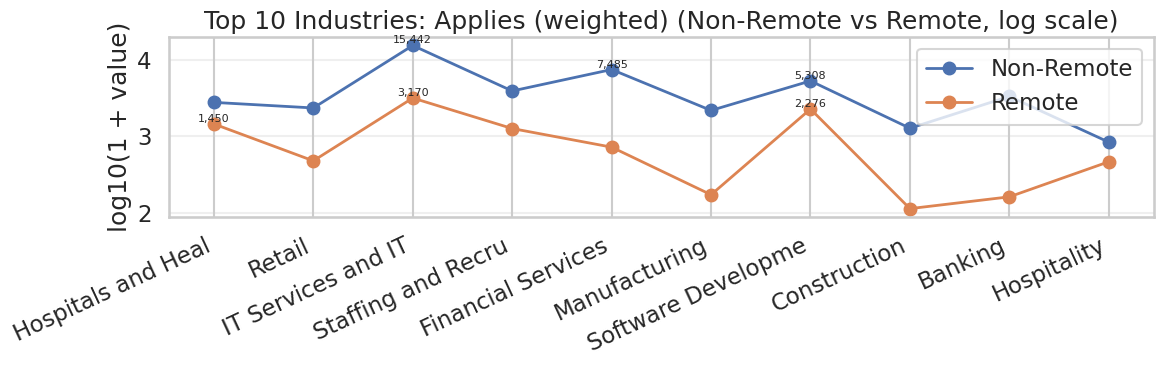

In [71]:
# =========================
# ONE Chart per metric (same graph):
# Non-Remote vs Remote (log10(1+x)) + labels
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 10
LABEL_MAX = 18
LABEL_TOP_K = 3   # ใส่ label เฉพาะจุดสูงสุดกี่จุด/เส้น (กันรก)

viz = agg.copy()
viz["group"] = np.where(viz["is_remote"], "Remote", "Non-Remote")

# เลือก Top industries ด้วย postings รวม (แกนเดียวกันทุกกราฟ)
top_ind = (viz.groupby("industry_name")["postings"].sum()
           .sort_values(ascending=False).head(TOP_N).index)

d = viz[viz["industry_name"].isin(top_ind)].copy()

def pivot_metric(metric):
    p = (d.pivot_table(index="industry_name", columns="group", values=metric, aggfunc="sum")
           .fillna(0))
    if "Non-Remote" not in p.columns:
        p["Non-Remote"] = 0
    if "Remote" not in p.columns:
        p["Remote"] = 0

    # เรียงตาม postings รวมเพื่อให้อ่านง่ายและสอดคล้องกัน
    order = (d.groupby("industry_name")["postings"].sum().sort_values(ascending=False).index)
    p = p.loc[order]
    return p

def plot_two_lines(metric, title):
    p = pivot_metric(metric)

    # log scale เพื่อบีบสเกล (เหมือนโค้ดล่าสุด)
    y_non = np.log10(p["Non-Remote"].astype(float) + 1)
    y_rem = np.log10(p["Remote"].astype(float) + 1)

    x = np.arange(len(p.index))
    labels = [s[:LABEL_MAX] for s in p.index]

    plt.figure(figsize=(12,4))
    plt.plot(x, y_non.values, marker="o", linewidth=2, label="Non-Remote")
    plt.plot(x, y_rem.values, marker="o", linewidth=2, label="Remote")

    # ใส่ label เป็น "ค่าจริง" เฉพาะจุดสูงสุด (กันรก)
    non_vals = p["Non-Remote"].values
    rem_vals = p["Remote"].values

    for idx in np.argsort(-non_vals)[:LABEL_TOP_K]:
        plt.text(x[idx], y_non.values[idx], f"{non_vals[idx]:,.0f}", fontsize=8, ha="center", va="bottom")
    for idx in np.argsort(-rem_vals)[:LABEL_TOP_K]:
        plt.text(x[idx], y_rem.values[idx], f"{rem_vals[idx]:,.0f}", fontsize=8, ha="center", va="bottom")

    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel("log10(1 + value)")
    plt.title(title + " (Non-Remote vs Remote, log scale)")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_two_lines("postings", f"Top {TOP_N} Industries: Postings")
plot_two_lines("views",    f"Top {TOP_N} Industries: Views (weighted)")
plot_two_lines("applies",  f"Top {TOP_N} Industries: Applies (weighted)")

## 5.4 USA: Remote vs Non-Remote Trend Over Time (2024)

**EN:** We focus on **USA postings in 2024** and compare Remote vs Non-Remote across the year:
- Monthly postings (Remote vs Non-Remote)
- Monthly applications (Remote vs Non-Remote)
- Remote share trend (Remote / Total)

**TH:** โฟกัสที่ **ประกาศงานใน USA ปี 2024** แล้วเทียบ Remote vs Non-Remote ตลอดทั้งปี:
- จำนวนประกาศงานรายเดือน (Remote vs Non-Remote)
- จำนวนผู้สมัครรายเดือน (Remote vs Non-Remote)
- แนวโน้มสัดส่วน Remote (Remote / Total)


,month,non_remote_posts,remote_posts,non_remote_applies,remote_applies,total_posts,remote_share,apply_rate_non_remote,apply_rate_remote
0,2024-01-01,3.0,0.0,16.0,0.0,3.0,0.000000,5.333333,NaN
1,2024-02-01,5.0,1.0,30.0,360.0,6.0,0.166667,6.000000,360.000000
2,2024-03-01,1523.0,67.0,920.0,90.0,1590.0,0.042138,0.604071,1.343284
3,2024-04-01,98005.0,4628.0,95726.0,20480.0,102633.0,0.045093,0.976746,4.425238


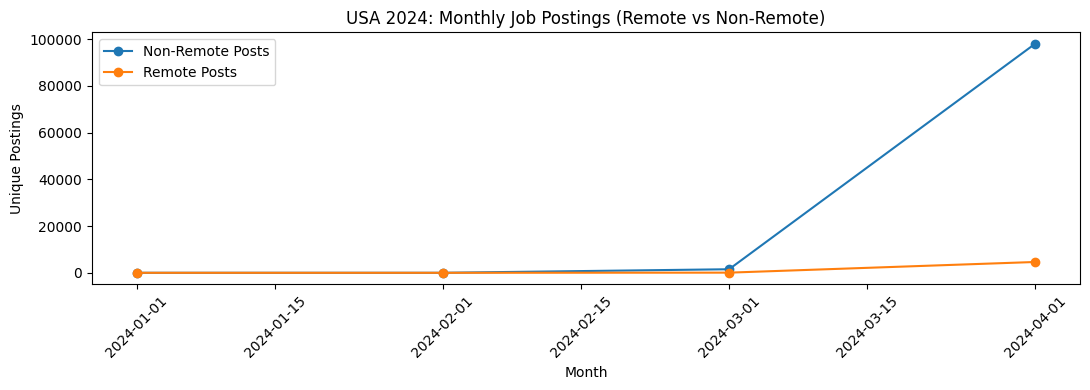

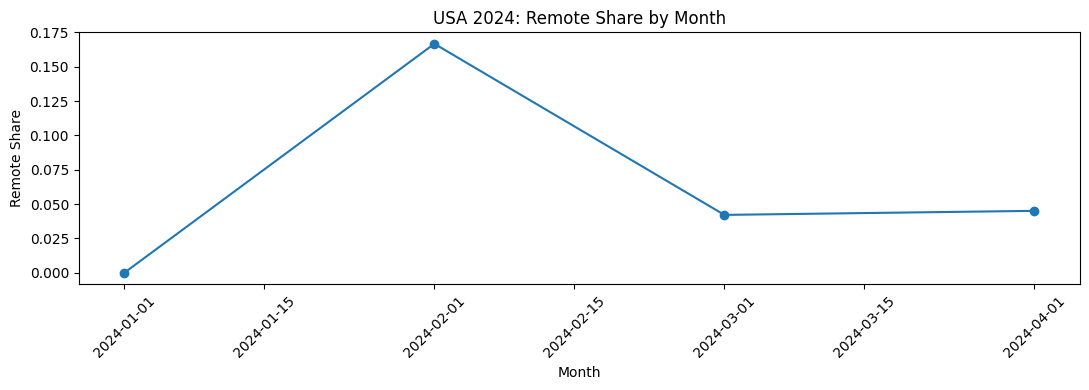

In [54]:
# --- Dataset: USA 2024 ---
df_usa_2024 = df_2024_usa.copy()

# Monthly table: postings + applies by Remote/Non-Remote
monthly = (df_usa_2024
           .groupby(["month","is_remote"])
           .agg(
               postings=("job_id","nunique"),
               applies=("applies","sum")
           )
           .reset_index())

# Pivot for a clean comparison table
piv_posts = monthly.pivot(index="month", columns="is_remote", values="postings").fillna(0)
piv_apps  = monthly.pivot(index="month", columns="is_remote", values="applies").fillna(0)

# columns: False=Non-Remote, True=Remote
out = pd.DataFrame({
    "non_remote_posts": piv_posts.get(False, 0),
    "remote_posts": piv_posts.get(True, 0),
    "non_remote_applies": piv_apps.get(False, 0),
    "remote_applies": piv_apps.get(True, 0),
}).reset_index()

out["total_posts"] = out["non_remote_posts"] + out["remote_posts"]
out["remote_share"] = (out["remote_posts"] / out["total_posts"].replace(0, np.nan))

# Apply rate (applies per posting)
out["apply_rate_non_remote"] = out["non_remote_applies"] / out["non_remote_posts"].replace(0, np.nan)
out["apply_rate_remote"] = out["remote_applies"] / out["remote_posts"].replace(0, np.nan)

display(out)

# Line chart (posts): Remote vs Non-Remote
plt.figure(figsize=(11,4))
plt.plot(out["month"], out["non_remote_posts"], marker="o", label="Non-Remote Posts")
plt.plot(out["month"], out["remote_posts"], marker="o", label="Remote Posts")
plt.title("USA 2024: Monthly Job Postings (Remote vs Non-Remote)")
plt.xlabel("Month")
plt.ylabel("Unique Postings")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Line chart (remote share)
plt.figure(figsize=(11,4))
plt.plot(out["month"], out["remote_share"], marker="o")
plt.title("USA 2024: Remote Share by Month")
plt.xlabel("Month")
plt.ylabel("Remote Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ✨ Improved Visualization (เพิ่มจากกราฟเดิม): USA Remote vs Non-Remote (2024)

**EN:** A cleaner comparison view with:
- Remote share + 3-month moving average (MA3)
- Remote vs Non-Remote postings in the same chart (secondary axis not used; keep simple)

**TH:** กราฟเปรียบเทียบที่อ่านง่ายขึ้น:
- Remote share พร้อมเส้นค่าเฉลี่ยเคลื่อนที่ 3 เดือน (MA3)
- เส้น Remote vs Non-Remote postings ในกราฟเดียวกัน


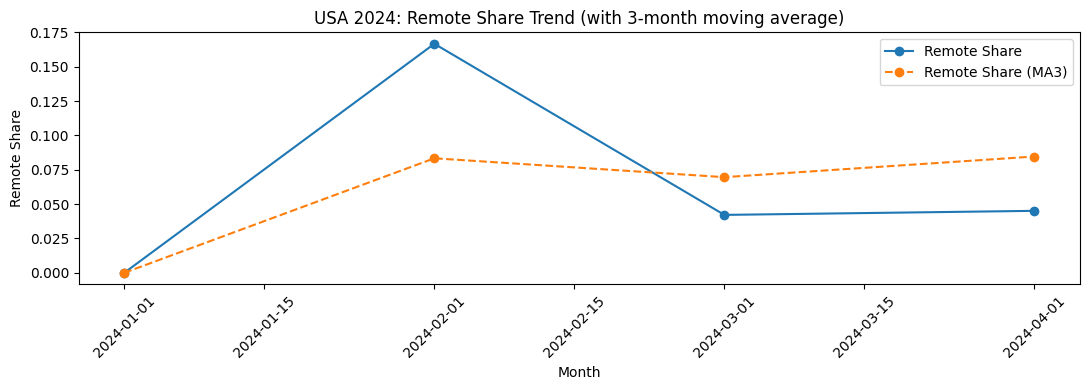

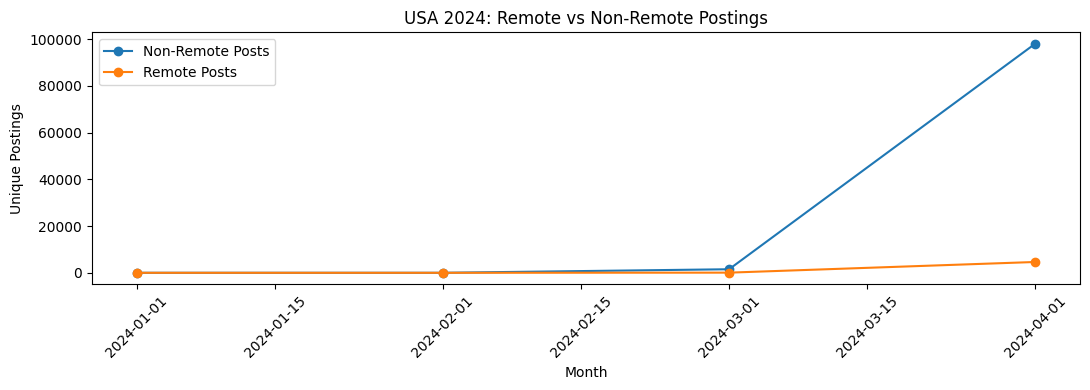

Auto-insights (USA 2024):
- Remote share start→end: 0.0% → 4.5% (Δ +4.5 pp)
- Peak remote share: 2024-02-01 = 16.7%
- Lowest remote share: 2024-01-01 = 0.0%


In [55]:
# ========== Pretty Trend Charts: USA 2024 ==========
usa = out.copy().sort_values("month")
usa["remote_share_ma3"] = usa["remote_share"].rolling(3, min_periods=1).mean()

# Chart 1: Remote share + MA3
plt.figure(figsize=(11,4))
plt.plot(usa["month"], usa["remote_share"], marker="o", label="Remote Share")
plt.plot(usa["month"], usa["remote_share_ma3"], marker="o", linestyle="--", label="Remote Share (MA3)")
plt.title("USA 2024: Remote Share Trend (with 3-month moving average)")
plt.xlabel("Month")
plt.ylabel("Remote Share")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Chart 2: Posts Remote vs Non-Remote
plt.figure(figsize=(11,4))
plt.plot(usa["month"], usa["non_remote_posts"], marker="o", label="Non-Remote Posts")
plt.plot(usa["month"], usa["remote_posts"], marker="o", label="Remote Posts")
plt.title("USA 2024: Remote vs Non-Remote Postings")
plt.xlabel("Month")
plt.ylabel("Unique Postings")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Auto-insights (text)
start = usa.iloc[0]["remote_share"]
end = usa.iloc[-1]["remote_share"]
delta_pp = (end - start) * 100
peak_row = usa.loc[usa["remote_share"].idxmax()]
low_row  = usa.loc[usa["remote_share"].idxmin()]

print("Auto-insights (USA 2024):")
print(f"- Remote share start→end: {start:.1%} → {end:.1%} (Δ {delta_pp:+.1f} pp)")
print(f"- Peak remote share: {peak_row['month'].date()} = {peak_row['remote_share']:.1%}")
print(f"- Lowest remote share: {low_row['month'].date()} = {low_row['remote_share']:.1%}")

## 5.5 USA 2024: Salary Comparison — Remote vs Non-Remote

**EN:** Compare salary distribution for Remote vs Non-Remote postings in **USA (2024)** using `normalized_salary`.  
**TH:** เปรียบเทียบการกระจายเงินเดือน Remote vs Non-Remote ใน **USA (ปี 2024)** โดยใช้ `normalized_salary`


,group,count,median,mean,p25,p75
0,Non-Remote,28092,75000.0,198853.730284,48880.0,117500.0
1,Remote,1442,114400.0,518160.681054,77562.5,154162.5


/tmp/ipython-input-407/404955433.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



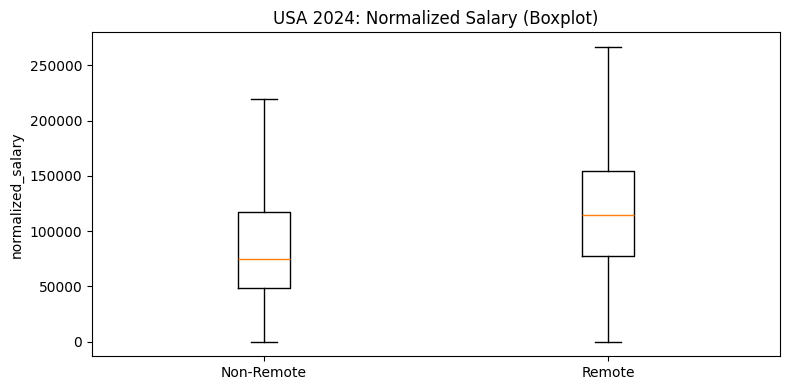

In [56]:
salary_df = df_2024_usa[df_2024_usa["normalized_salary"].notna()].copy()

# Basic summary table
sal_sum = (salary_df.groupby("is_remote")["normalized_salary"]
           .agg(count="count", median="median", mean="mean", p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
           .reset_index())
sal_sum["group"] = np.where(sal_sum["is_remote"], "Remote", "Non-Remote")
display(sal_sum[["group","count","median","mean","p25","p75"]])

# Original (simple) plot: boxplot
plt.figure(figsize=(8,4))
data = [
    salary_df.loc[~salary_df["is_remote"], "normalized_salary"],
    salary_df.loc[salary_df["is_remote"], "normalized_salary"]
]
plt.boxplot(data, labels=["Non-Remote","Remote"], showfliers=False)
plt.title("USA 2024: Normalized Salary (Boxplot)")
plt.ylabel("normalized_salary")
plt.tight_layout()
plt.show()

### ✨ Improved Visualization (เพิ่มจากกราฟเดิม): Salary Distribution — Remote vs Non-Remote (2024)

**แนวคิด/ความต่างจากกราฟเดิม**
- กราฟเดิม: boxplot แบบพื้นฐาน → เห็น median/ช่วงกระจาย แต่ “รูปทรง distribution” ยังไม่ชัด (เช่น โหนก, หางยาว)
- กราฟใหม่นี้:
  1) เพิ่ม **Violin + Box** เพื่อเห็นทั้ง distribution และ summary ในภาพเดียว  
  2) เพิ่ม **Histogram (density)** เพื่อดูการกระจายแบบละเอียด  
  3) ใส่ **annotation** สรุปความต่างของ median (Remote vs Non-Remote)

> หมายเหตุ: ใช้ normalized_salary เฉพาะค่ามากกว่า 0 และไม่ว่าง (notna)

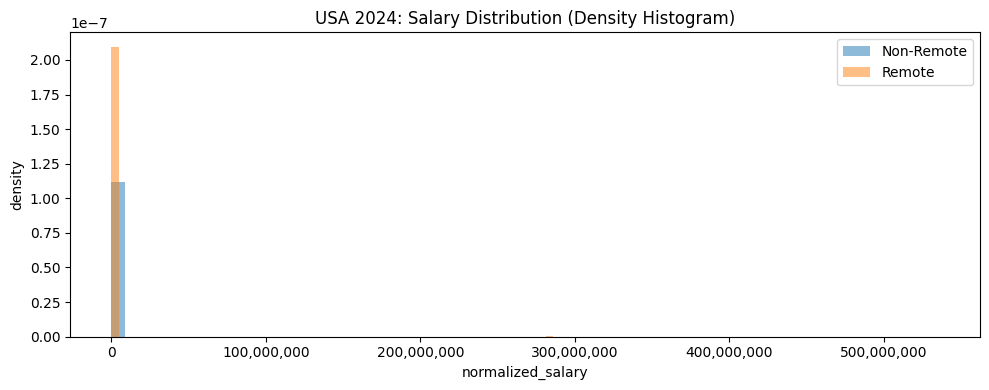

/tmp/ipython-input-407/621268395.py:35: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



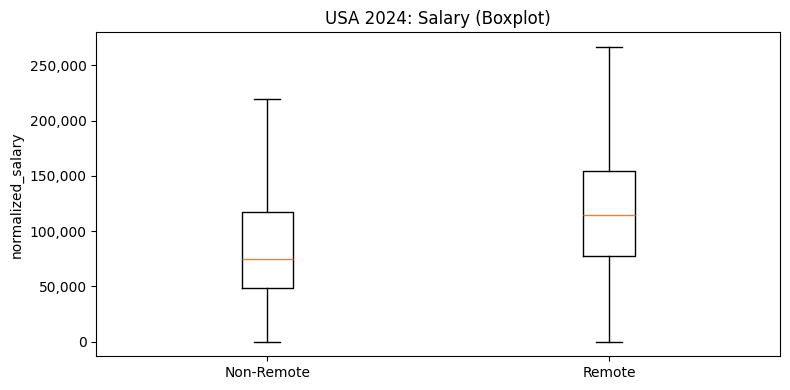

Median salary: Remote=114,400 vs Non-Remote=75,000 (Δ +52.5%)


In [57]:
# ========== Pretty Salary Charts (USA 2024): Remote vs Non-Remote ==========
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# Safety (if salary_df not created)
if "salary_df" not in globals():
    salary_df = df_2024_usa[df_2024_usa["normalized_salary"].notna()].copy()

def fmt_money(x, pos):
    # show as 1,000,000 style (keep unit as dataset unit)
    try:
        return f"{x:,.0f}"
    except Exception:
        return str(x)

# Prepare groups
non = salary_df.loc[~salary_df["is_remote"], "normalized_salary"].dropna()
rem = salary_df.loc[salary_df["is_remote"], "normalized_salary"].dropna()

# 1) Violin-like (hist density approximation) + boxplot (matplotlib-only)
plt.figure(figsize=(10,4))
plt.hist(non, bins=60, alpha=0.5, density=True, label="Non-Remote")
plt.hist(rem, bins=60, alpha=0.5, density=True, label="Remote")
plt.title("USA 2024: Salary Distribution (Density Histogram)")
plt.xlabel("normalized_salary")
plt.ylabel("density")
plt.legend()
plt.gca().xaxis.set_major_formatter(FuncFormatter(fmt_money))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot([non, rem], labels=["Non-Remote","Remote"], showfliers=False)
plt.title("USA 2024: Salary (Boxplot)")
plt.ylabel("normalized_salary")
plt.gca().yaxis.set_major_formatter(FuncFormatter(fmt_money))
plt.tight_layout()
plt.show()

# Quick text insight
med_non = float(np.nanmedian(non)) if len(non) else np.nan
med_rem = float(np.nanmedian(rem)) if len(rem) else np.nan
if np.isfinite(med_non) and np.isfinite(med_rem) and med_non != 0:
    diff_pct = (med_rem - med_non) / med_non * 100
    print(f"Median salary: Remote={med_rem:,.0f} vs Non-Remote={med_non:,.0f} (Δ {diff_pct:+.1f}%)")
else:
    print(f"Median salary: Remote={med_rem} vs Non-Remote={med_non}")

### 5.5.1 อุตสาหกรรมที่ “เงินเดือนสูงที่สุด” (Top 10) — แยก Remote vs Non-Remote (USA 2024)

**EN:** Identify industries with the highest **median normalized salary** for Remote and Non-Remote postings (USA 2024).  
**TH:** หาอุตสาหกรรมที่มี **เงินเดือน (median normalized_salary) สูงที่สุด** แยก Remote vs Non-Remote (USA ปี 2024)

> หมายเหตุ: งานหนึ่งอาจอยู่ได้หลายอุตสาหกรรม (multi-industry). เราใช้ 1 แถวต่อ (job_id, industry) เพื่อสรุปภาพรวมของอุตสาหกรรม


,group,industry_name,postings,median_salary
0,Remote,Software Development,191,144560.0
1,Remote,Business Consulting and Services,51,135000.0
2,Remote,"Technology, Information and Internet",52,131500.0
3,Remote,Staffing and Recruiting,125,125000.0
4,Remote,Financial Services,148,121492.5
5,Remote,Biotechnology Research,46,120612.5
6,Remote,Pharmaceutical Manufacturing,61,120612.5
7,Remote,IT Services and IT Consulting,178,119800.0
8,Remote,Accounting,46,115000.0
9,Remote,Medical Equipment Manufacturing,38,109412.5


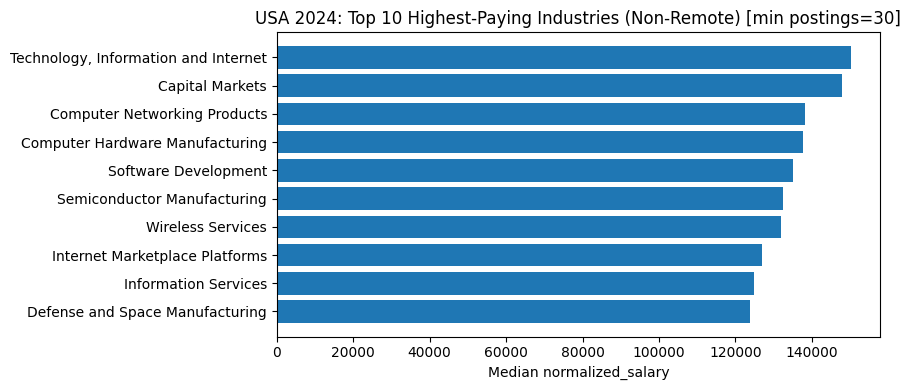

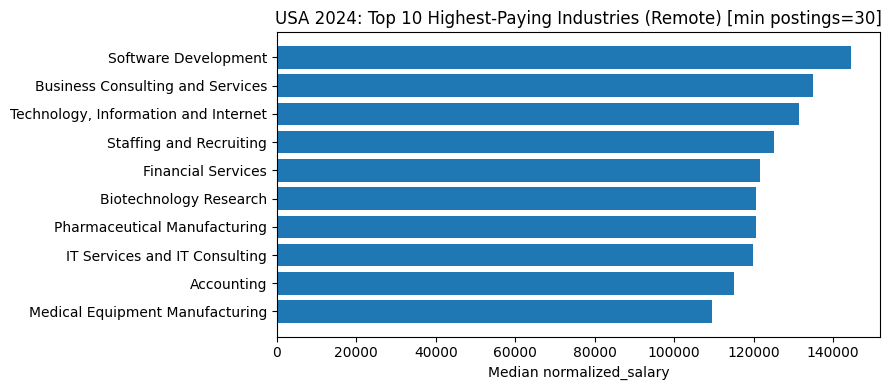

In [58]:
# --- Industry salary (USA 2024) ---
base_ind = df_merged.copy()

ind_col = None
for cand in ["industry_name","industry","industryName","name"]:
    if cand in base_ind.columns:
        ind_col = cand
        break
if ind_col is None:
    raise ValueError("Cannot find industry name column in df_merged")

ji_sal = base_ind[["job_id", ind_col]].dropna().drop_duplicates().rename(columns={ind_col:"industry_name"})
ji_sal = ji_sal.merge(
    df_2024_usa[["job_id","is_remote","normalized_salary"]],
    on="job_id",
    how="inner"
)
ji_sal = ji_sal.dropna(subset=["normalized_salary"])

# Aggregate by industry and remote flag
ind_sal = (ji_sal.groupby(["is_remote","industry_name"])
           .agg(
               postings=("job_id","nunique"),
               median_salary=("normalized_salary","median")
           )
           .reset_index())

# Filter to reduce noise (min postings)
min_n = 30
if (ind_sal["postings"] >= min_n).sum() < 20:
    min_n = 10  # relax if dataset is smaller
ind_sal_f = ind_sal[ind_sal["postings"] >= min_n].copy()

def top10_salary(is_remote: bool):
    d = ind_sal_f[ind_sal_f["is_remote"]==is_remote].sort_values("median_salary", ascending=False).head(10).copy()
    d["group"] = "Remote" if is_remote else "Non-Remote"
    return d[["group","industry_name","postings","median_salary"]]

top_sal_remote = top10_salary(True)
top_sal_non = top10_salary(False)

display(pd.concat([top_sal_remote, top_sal_non], ignore_index=True))

# Bar charts
def barh_salary(d, title):
    plt.figure(figsize=(9,4))
    plt.barh(d["industry_name"][::-1], d["median_salary"][::-1])
    plt.title(title)
    plt.xlabel("Median normalized_salary")
    plt.tight_layout()
    plt.show()

barh_salary(top_sal_non, f"USA 2024: Top 10 Highest-Paying Industries (Non-Remote) [min postings={min_n}]")
barh_salary(top_sal_remote, f"USA 2024: Top 10 Highest-Paying Industries (Remote) [min postings={min_n}]")

## 5.6 USA 2024: Skills Analysis (Remote vs Non-Remote)

**EN:** Identify popular skills and skills associated with higher salaries in **USA (2024)**.  
**TH:** วิเคราะห์ทักษะที่พบบ่อย และทักษะที่สัมพันธ์กับเงินเดือนสูง ใน **USA (ปี 2024)** โดยแยก Remote vs Non-Remote


In [59]:
# --- Helper: detect join key between job_skills and skills ---
def detect_skill_key(df_job_skills, df_skills):
    candidates = [("skill_id","skill_id"), ("skill_abr","skill_abr"), ("skill_abr","skill_id"), ("skill_id","skill_abr")]
    for a,b in candidates:
        if a in df_job_skills.columns and b in df_skills.columns:
            return a,b
    raise ValueError("Cannot detect skill join key. Please check columns in df_job_skills / df_skills.")

js_key, sk_key = detect_skill_key(df_job_skills, df_skills)
print("Using skill join keys:", js_key, "->", sk_key)

# 1) Map skill_name
job_skills_named = df_job_skills.merge(df_skills, left_on=js_key, right_on=sk_key, how="left")
# Expect a column 'skill_name'
if "skill_name" not in job_skills_named.columns:
    # sometimes column may be named differently; show columns for manual fix
    print("Columns in job_skills_named:", job_skills_named.columns.tolist())
    raise ValueError("Missing skill_name. Please identify correct column name in skills table.")
job_skills_named = job_skills_named.dropna(subset=["skill_name"]).copy()

# 2) Join with job-level 2024 postings
skills_2024 = df_2024_usa[["job_id","is_remote","location_transformed_refined","normalized_salary"]].merge(
    job_skills_named[["job_id","skill_name"]],
    on="job_id",
    how="inner"
)

print("skills_2024 rows:", len(skills_2024), "unique jobs:", skills_2024["job_id"].nunique())
display(skills_2024.head())

Using skill join keys: skill_abr -> skill_abr
skills_2024 rows: 172323 unique jobs: 103199


,job_id,is_remote,location_transformed_refined,normalized_salary,skill_name
0,921716,False,USA,38480.0,Marketing
1,921716,False,USA,38480.0,Sales
2,10998357,False,USA,55000.0,Management
3,10998357,False,USA,55000.0,Manufacturing
4,23221523,False,USA,157500.0,Other


,skill_name,count
0,Information Technology,20188
1,Management,18570
2,Sales,17379
3,Manufacturing,16480
4,Health Care Provider,15470
5,Other,11021
6,Business Development,10647
7,Engineering,10080
8,Finance,6583
9,Accounting/Auditing,4120


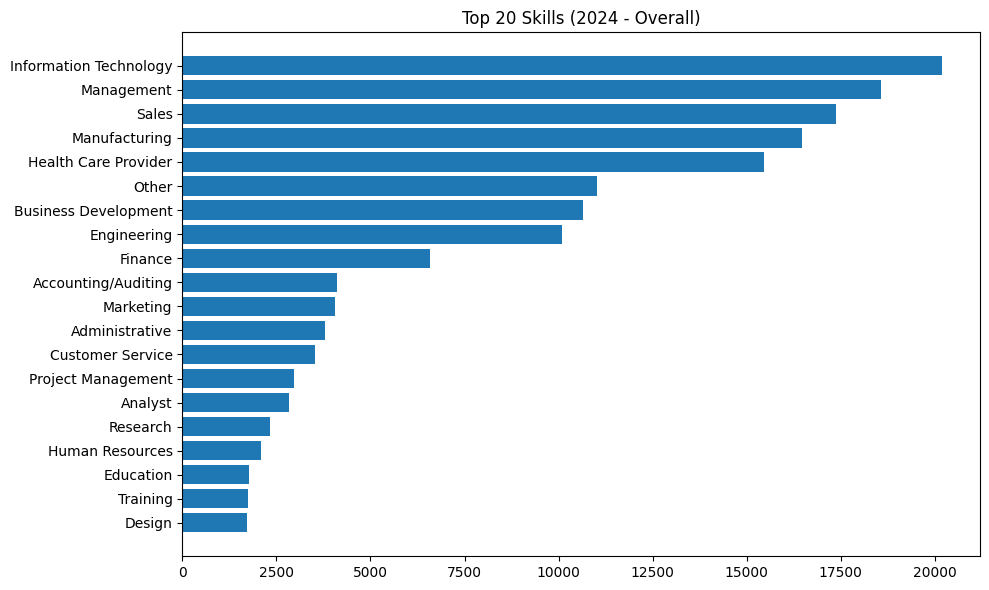

In [60]:
top_skills = skills_2024["skill_name"].value_counts().head(20).reset_index()
top_skills.columns = ["skill_name","count"]
display(top_skills)

plt.figure(figsize=(10,6))
plt.barh(top_skills["skill_name"][::-1], top_skills["count"][::-1])
plt.title("Top 20 Skills (2024 - Overall)")
plt.tight_layout()
plt.show()

,skill_name,n_jobs,median,mean
22,Product Management,352,142700.0,1.448608e+05
31,Strategy/Planning,321,120000.0,1.289785e+05
11,Engineering,3009,115000.0,2.845256e+05
24,Project Management,1067,112500.0,1.162055e+05
17,Legal,736,112500.0,1.113140e+06
16,Information Technology,5647,109200.0,3.003557e+05
6,Consulting,517,107500.0,1.179526e+05
2,Advertising,141,94050.0,1.059193e+05
28,Research,777,90000.0,1.065911e+05
12,Finance,2324,88400.0,2.523051e+05


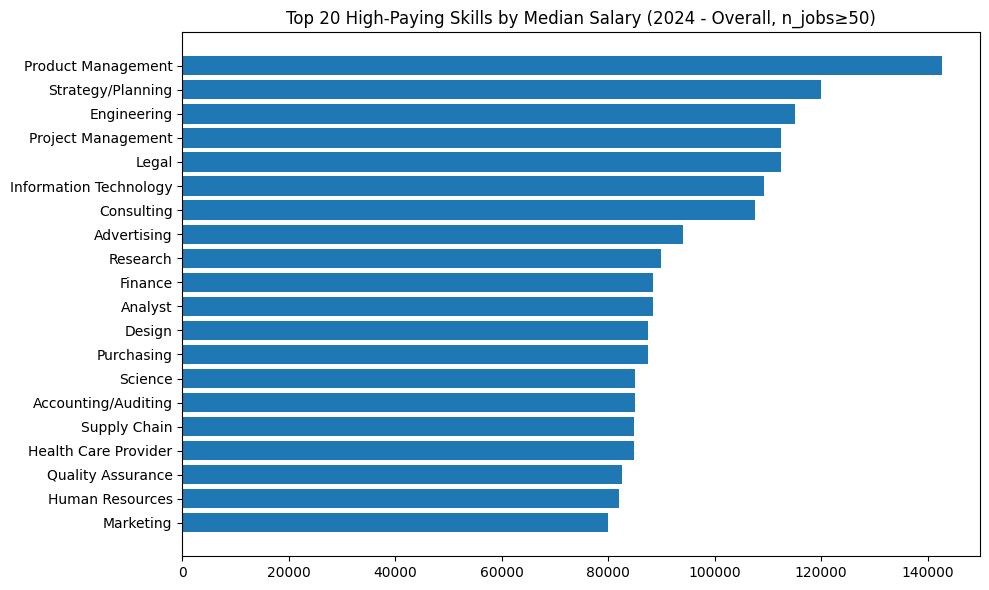

In [61]:
skill_salary = skills_2024.dropna(subset=["normalized_salary"]).copy()
skill_salary = skill_salary[skill_salary["normalized_salary"] > 0].copy()

skill_stats = (skill_salary.groupby("skill_name")
               .agg(
                   n_jobs=("job_id","nunique"),
                   median=("normalized_salary","median"),
                   mean=("normalized_salary","mean")
               )
               .reset_index()
              )

min_jobs = 50
skill_stats_filtered = (skill_stats[skill_stats["n_jobs"] >= min_jobs]
                        .sort_values("median", ascending=False)
                        .head(20))

display(skill_stats_filtered)

plt.figure(figsize=(10,6))
plt.barh(skill_stats_filtered["skill_name"][::-1], skill_stats_filtered["median"][::-1])
plt.title(f"Top 20 High-Paying Skills by Median Salary (2024 - Overall, n_jobs≥{min_jobs})")
plt.tight_layout()
plt.show()

,skill_name,n_jobs,median,mean
10,Engineering,161,150000.0000,1.604683e+05
13,Health Care Provider,74,137950.2225,1.323336e+05
6,Consulting,52,132250.0000,1.280538e+05
15,Information Technology,456,130000.0000,1.388676e+06
21,Product Management,49,120612.5000,1.508344e+05
3,Analyst,50,115960.0000,1.171419e+05
23,Project Management,73,112500.0000,1.173893e+05
11,Finance,139,110000.0000,1.168940e+05
5,Business Development,212,110000.0000,1.249025e+05
0,Accounting/Auditing,75,109200.0000,1.105087e+05


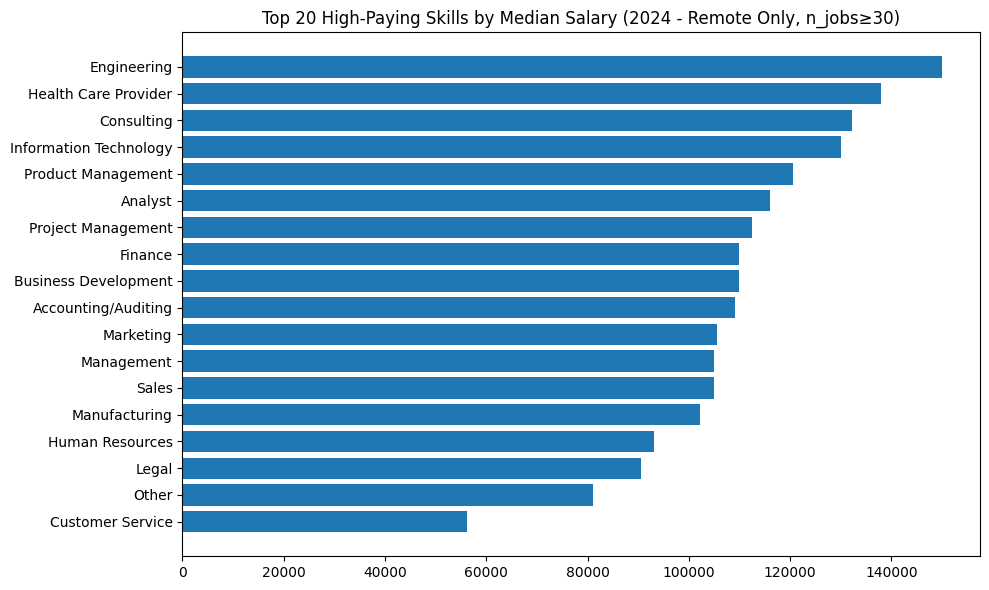

In [62]:
remote_only = skill_salary[skill_salary["is_remote"]].copy()

remote_skill_stats = (remote_only.groupby("skill_name")
                      .agg(
                          n_jobs=("job_id","nunique"),
                          median=("normalized_salary","median"),
                          mean=("normalized_salary","mean")
                      )
                      .reset_index()
                     )

min_jobs_remote = 30
remote_skill_stats_filtered = (remote_skill_stats[remote_skill_stats["n_jobs"] >= min_jobs_remote]
                               .sort_values("median", ascending=False)
                               .head(20))

display(remote_skill_stats_filtered)

plt.figure(figsize=(10,6))
plt.barh(remote_skill_stats_filtered["skill_name"][::-1], remote_skill_stats_filtered["median"][::-1])
plt.title(f"Top 20 High-Paying Skills by Median Salary (2024 - Remote Only, n_jobs≥{min_jobs_remote})")
plt.tight_layout()
plt.show()

### ✨ Improved Visualization (เพิ่มจากกราฟเดิม): Skills × Salary × Remote (USA 2024)

**แนวคิด/ความต่างจากกราฟเดิม**
- กราฟเดิม: bar chart แยก “Top skills” และ “High-paying skills” → อ่านได้ แต่ยังไม่เห็น *trade-off* ระหว่าง
  - ความนิยม (จำนวนงานที่พบ skill นั้น)  
  - รายได้ (median salary)  
  - ความเป็น Remote (remote share)
- กราฟใหม่นี้: ทำเป็น **Bubble Scatter**  
  - แกน X = จำนวนงาน (n_jobs)  
  - แกน Y = median salary  
  - ขนาด bubble = n_jobs  
  - สี = remote share (ยิ่งเข้มยิ่ง remote มาก)

> ช่วยให้เห็นภาพรวมว่า “สกิลไหนทั้งนิยม + เงินดี + remote สูง” ในกราฟเดียว

,skill_name,n_jobs,median_salary,remote_share
16,Information Technology,20188,109200.0,0.064940
18,Management,18570,56363.2,0.011632
29,Sales,17379,70000.0,0.088095
19,Manufacturing,16480,53194.5,0.009284
14,Health Care Provider,15470,84791.2,0.016677
21,Other,11021,56633.0,0.023410
5,Business Development,10647,71000.0,0.102752
11,Engineering,10080,115000.0,0.061607
12,Finance,6583,88400.0,0.057573
0,Accounting/Auditing,4120,85000.0,0.043204


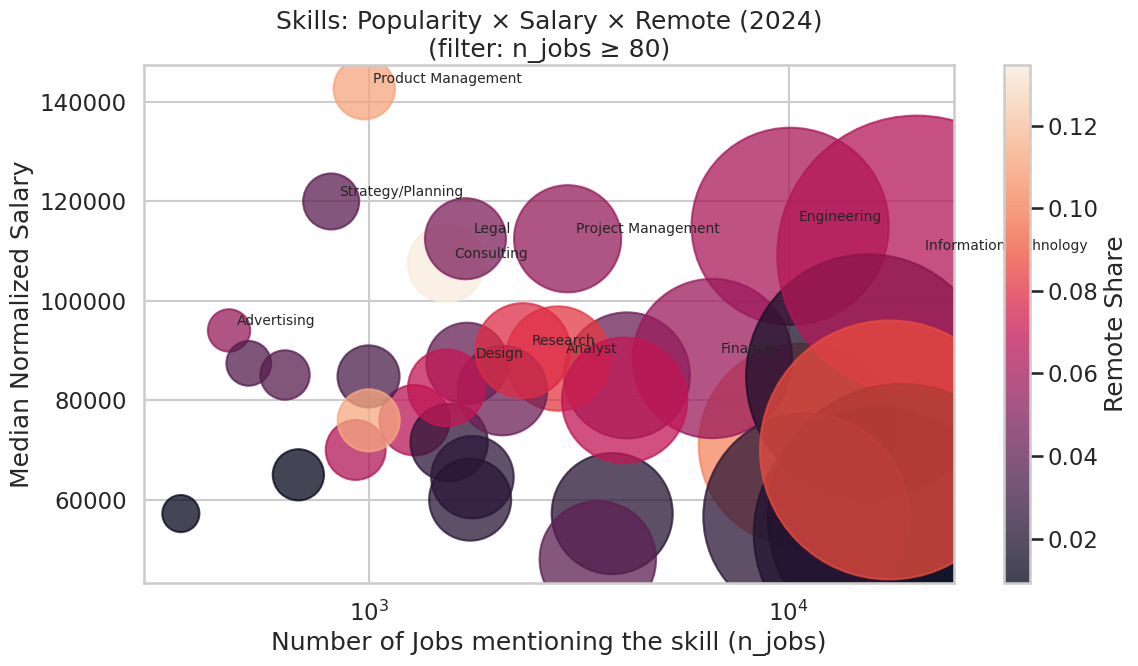

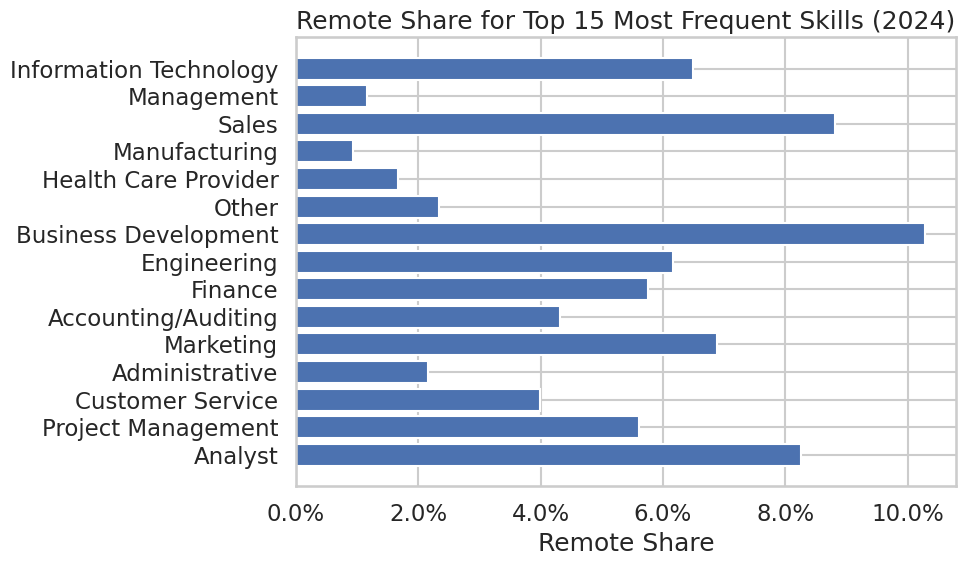

🔎 Interpretation (EN):
- Bubble chart helps spot skills that are BOTH popular (right), high-paying (up), and remote-friendly (color).
- Readability tip: because X is log-scaled, a small move right can mean a big jump in job counts.

Top 5 popular skills (by n_jobs):


,skill_name,n_jobs,median_salary,remote_share
16,Information Technology,20188,109200.0,0.064940
18,Management,18570,56363.2,0.011632
29,Sales,17379,70000.0,0.088095
19,Manufacturing,16480,53194.5,0.009284
14,Health Care Provider,15470,84791.2,0.016677



Top 5 high-paying skills (by median salary):


,skill_name,n_jobs,median_salary,remote_share
22,Product Management,976,142700.0,0.111680
31,Strategy/Planning,814,120000.0,0.039312
11,Engineering,10080,115000.0,0.061607
24,Project Management,2976,112500.0,0.056116
17,Legal,1700,112500.0,0.049412



Top 5 most remote-friendly among popular skills (filtered):


,skill_name,n_jobs,median_salary,remote_share
6,Consulting,1530,107500.0,0.134641
34,Writing/Editing,1000,75960.0,0.113000
22,Product Management,976,142700.0,0.111680
5,Business Development,10647,71000.0,0.102752
29,Sales,17379,70000.0,0.088095



🔎 คำอธิบาย (TH):
- Bubble chart ช่วยเห็น ‘สกิลที่นิยม (ไปทางขวา) + เงินดี (สูงขึ้น) + Remote สูง (สีเข้ม)’ ในกราฟเดียว
- แกน X เป็น log scale: ขยับไปทางขวาเล็กน้อย อาจหมายถึงจำนวนงานเพิ่มขึ้นมาก


In [63]:
# ========== Pretty Skill Bubble Chart (2024) ==========
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import numpy as np

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
except Exception as e:
    print("seaborn not available, fallback to matplotlib only:", e)

# Build skill summary (job-level count + median salary + remote share)
skill_bubble = (skills_2024
                .dropna(subset=["skill_name"])
                .groupby("skill_name")
                .agg(
                    n_jobs=("job_id","nunique"),
                    median_salary=("normalized_salary","median"),
                    remote_share=("is_remote","mean"),
                )
                .reset_index()
               )

# keep meaningful rows
skill_bubble = skill_bubble.dropna(subset=["median_salary"]).copy()
skill_bubble = skill_bubble[skill_bubble["median_salary"] > 0].copy()

min_jobs_bubble = 80  # ปรับได้
skill_bubble_f = skill_bubble[skill_bubble["n_jobs"] >= min_jobs_bubble].copy()

# pick top for labeling (high median among popular)
label_df = (skill_bubble_f
            .sort_values(["median_salary","n_jobs"], ascending=False)
            .head(12)
           )

display(skill_bubble_f.sort_values("n_jobs", ascending=False).head(10))

# ---- Bubble plot ----
fig, ax = plt.subplots(figsize=(12, 7))

sizes = skill_bubble_f["n_jobs"] * 2.0  # scale bubble size
sc = ax.scatter(skill_bubble_f["n_jobs"], skill_bubble_f["median_salary"],
                s=sizes, c=skill_bubble_f["remote_share"], alpha=0.75)

ax.set_title(f"Skills: Popularity × Salary × Remote (2024)\n(filter: n_jobs ≥ {min_jobs_bubble})")
ax.set_xlabel("Number of Jobs mentioning the skill (n_jobs)")
ax.set_ylabel("Median Normalized Salary")
ax.set_xscale("log")  # ทำให้เห็นช่วง n_jobs ชัดขึ้น

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Remote Share")

# label a few standout skills
for _, r in label_df.iterrows():
    ax.annotate(r["skill_name"], (r["n_jobs"], r["median_salary"]),
                textcoords="offset points", xytext=(6, 4), fontsize=10)

plt.tight_layout()
plt.show()

# Optional: Remote share for top skills (frequency)
topN = 15
top_freq = (skills_2024.groupby("skill_name")
            .agg(n_jobs=("job_id","nunique"),
                 remote_share=("is_remote","mean"))
            .reset_index()
            .sort_values("n_jobs", ascending=False)
            .head(topN)
           )

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_freq["skill_name"][::-1], top_freq["remote_share"][::-1])
ax.set_title(f"Remote Share for Top {topN} Most Frequent Skills (2024)")
ax.set_xlabel("Remote Share")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

# --- Auto-insights (ข้อความอธิบายอัตโนมัติ) ---
# Popular skills
top_pop = skill_bubble.sort_values("n_jobs", ascending=False).head(10)
top_pay = skill_bubble.sort_values(["median_salary","n_jobs"], ascending=False).head(10)
top_remote = skill_bubble_f.sort_values(["remote_share","n_jobs"], ascending=False).head(10) if len(skill_bubble_f) else pd.DataFrame()

print("🔎 Interpretation (EN):")
print("- Bubble chart helps spot skills that are BOTH popular (right), high-paying (up), and remote-friendly (color).")
print("- Readability tip: because X is log-scaled, a small move right can mean a big jump in job counts.")
print("\nTop 5 popular skills (by n_jobs):")
display(top_pop.head(5))
print("\nTop 5 high-paying skills (by median salary):")
display(top_pay.head(5))
if len(top_remote):
    print("\nTop 5 most remote-friendly among popular skills (filtered):")
    display(top_remote.head(5))

print("\n🔎 คำอธิบาย (TH):")
print("- Bubble chart ช่วยเห็น ‘สกิลที่นิยม (ไปทางขวา) + เงินดี (สูงขึ้น) + Remote สูง (สีเข้ม)’ ในกราฟเดียว")
print("- แกน X เป็น log scale: ขยับไปทางขวาเล็กน้อย อาจหมายถึงจำนวนงานเพิ่มขึ้นมาก")

## Key Findings & Conclusion (USA-focused)

**EN:** Key takeaways from our USA 2024 deep-dive:
1) **Location footprint:** which cities appear in USA vs Other (and the map overview)  
2) **Remote vs Non-Remote trend (USA 2024):** monthly postings + remote share  
3) **Industry (USA 2024):** Top industries by postings/views/applies split by Remote vs Non-Remote  
4) **Salary (USA 2024):** Remote vs Non-Remote salary distribution + highest-paying industries  
5) **Skills (USA 2024):** popular skills + skills associated with higher salaries (and remote share)

**Limitations (EN):**
- Salary coverage is partial (not all jobs report salary).
- Applies/views may be missing for some jobs.
- Industry mapping is many-to-many (a job can belong to multiple industries).
- Location grouping is simplified (USA vs Other).

---

**TH:** สรุปประเด็นสำคัญ (โฟกัส USA ปี 2024):
1) **ภาพรวม location:** มีประกาศงานอยู่เมืองอะไรบ้างใน USA vs Other (พร้อมแผนที่)  
2) **Remote vs Non-Remote trend (USA 2024):** จำนวนงานรายเดือน + สัดส่วน Remote  
3) **Industry (USA 2024):** อุตสาหกรรม Top ตาม postings/views/applies แยก Remote vs Non-Remote  
4) **Salary (USA 2024):** การกระจายเงินเดือน Remote vs Non-Remote + อุตสาหกรรมที่เงินเดือนสูงสุด  
5) **Skills (USA 2024):** ทักษะยอดนิยม + ทักษะที่สัมพันธ์กับเงินเดือนสูง (และ remote share)

**ข้อจำกัด (TH):**
- ข้อมูลเงินเดือนไม่ครบทุกงาน (salary coverage)
- ข้อมูล applies/views อาจขาดหายบางส่วน
- งานหนึ่งอาจอยู่ได้หลายอุตสาหกรรม (many-to-many)
- การแบ่ง location เป็น USA vs Other เป็นการจัดกลุ่มแบบหยาบ


In [64]:
# Quick numbers for writing the conclusion (USA 2024)

# Remote share (USA 2024)
remote_share_usa = df_2024_usa["is_remote"].mean()
print(f"USA 2024: Remote share = {remote_share_usa:.2%}")

# Salary coverage (USA 2024)
salary_cov_usa = df_2024_usa["normalized_salary"].notna().mean() * 100
print(f"USA 2024: Salary coverage = {salary_cov_usa:.2f}% (jobs with normalized_salary)")

# Median salary Remote vs Non-Remote (USA 2024)
sal_med = (df_2024_usa.dropna(subset=["normalized_salary"])
           .groupby("is_remote")["normalized_salary"]
           .median())
med_non = float(sal_med.get(False, np.nan))
med_rem = float(sal_med.get(True, np.nan))
print(f"USA 2024: Median salary Non-Remote = {med_non:,.0f}")
print(f"USA 2024: Median salary Remote     = {med_rem:,.0f}")

if np.isfinite(med_non) and np.isfinite(med_rem) and med_non != 0:
    print(f"USA 2024: Remote premium (median) = {(med_rem-med_non)/med_non*100:+.1f}%")

USA 2024: Remote share = 4.51%
USA 2024: Salary coverage = 28.33% (jobs with normalized_salary)
USA 2024: Median salary Non-Remote = 75,000
USA 2024: Median salary Remote     = 114,400
USA 2024: Remote premium (median) = +52.5%


## 6.0 Additional Analyses (Optional) — USA 2024

**EN:** Extra insights you can include to strengthen the story (all computed with pandas):  
- Engagement funnel: views → applies (by Remote vs Non-Remote)  
- Remote premium by work_type (median salary difference)  
- Top companies by posting volume (Remote vs Non-Remote)

**TH:** ไอเดียวิเคราะห์เพิ่มเติมเพื่อให้รายงาน “มีมิติ” มากขึ้น (ทำด้วย pandas ได้ทั้งหมด):  
- Funnel การมีส่วนร่วม: views → applies (แยก Remote vs Non-Remote)  
- Remote premium แยกตาม work_type (เงินเดือน median ต่างกันเท่าไร)  
- บริษัทที่ประกาศงานมากสุด (Remote vs Non-Remote)


,group,postings,views,applies,apply_per_view,apply_per_post
0,Non-Remote,99536,993475.0,96692.0,0.097327,0.971427
1,Remote,4696,105819.0,20930.0,0.197791,4.456985


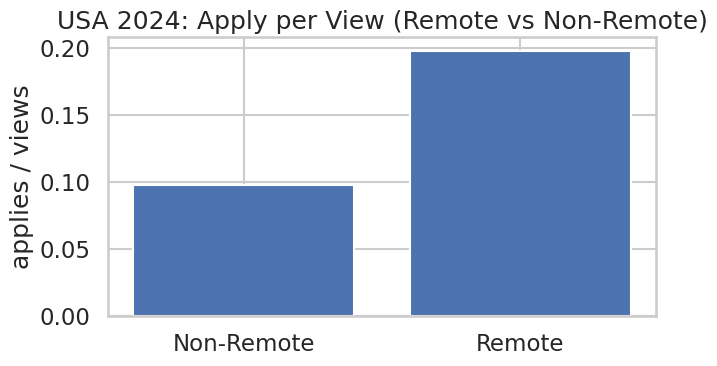

Remote premium by work_type (median salary) — higher means Remote pays more


,work_type,non_remote_median,remote_median,n_non_remote,n_remote,remote_premium_pct
3,OTHER,57200.0,176800.0,122.0,1.0,209.090909
4,PART_TIME,41600.0,78000.0,2033.0,19.0,87.500000
1,FULL_TIME,78000.0,115000.0,22758.0,1158.0,47.435897
5,TEMPORARY,54150.0,72800.0,345.0,11.0,34.441367
0,CONTRACT,88400.0,115000.0,2644.0,239.0,30.090498
2,INTERNSHIP,46800.0,40040.0,187.0,14.0,-14.444444
6,VOLUNTEER,50000.0,NaN,3.0,NaN,NaN


,is_remote,company_name,postings,group
9661,False,Liberty Healthcare and Rehabilitation Services,1077,Non-Remote
16491,False,The Job Network,991,Non-Remote
9871,False,"Lowe's Companies, Inc.",526,Non-Remote
19756,True,J. Galt,516,Remote
8377,False,Ingersoll Rand,501,Non-Remote
3095,False,Capital One,495,Non-Remote
15828,False,TEKsystems,452,Non-Remote
3838,False,Cogent Communications,410,Non-Remote
18208,False,Wells Fargo,386,Non-Remote
3568,False,Circle K,378,Non-Remote


In [65]:
df_base = df_2024_usa.copy()

# 6.0.1 Engagement funnel: Views -> Applies
funnel = (df_base.groupby("is_remote")
          .agg(
              postings=("job_id","nunique"),
              views=("views","sum"),
              applies=("applies","sum")
          )
          .reset_index())
funnel["group"] = np.where(funnel["is_remote"], "Remote", "Non-Remote")
funnel["apply_per_view"] = funnel["applies"] / funnel["views"].replace(0, np.nan)
funnel["apply_per_post"] = funnel["applies"] / funnel["postings"].replace(0, np.nan)
display(funnel[["group","postings","views","applies","apply_per_view","apply_per_post"]])

plt.figure(figsize=(7,4))
plt.bar(funnel["group"], funnel["apply_per_view"])
plt.title("USA 2024: Apply per View (Remote vs Non-Remote)")
plt.ylabel("applies / views")
plt.tight_layout()
plt.show()

# 6.0.2 Remote premium by work_type (if available)
if "work_type" in df_base.columns and "normalized_salary" in df_base.columns:
    prem = df_base.dropna(subset=["normalized_salary"]).groupby(["work_type","is_remote"]).agg(
        n=("job_id","nunique"),
        median_salary=("normalized_salary","median")
    ).reset_index()

    # Pivot remote vs non-remote
    piv = prem.pivot_table(index="work_type", columns="is_remote", values="median_salary")
    piv.columns = ["non_remote_median" if c is False else "remote_median" for c in piv.columns]
    piv = piv.reset_index()

    # attach n (min across groups) for stability
    n_piv = prem.pivot_table(index="work_type", columns="is_remote", values="n")
    n_piv.columns = ["n_non_remote" if c is False else "n_remote" for c in n_piv.columns]
    n_piv = n_piv.reset_index()

    piv = piv.merge(n_piv, on="work_type", how="left")
    piv["remote_premium_pct"] = (piv["remote_median"] - piv["non_remote_median"]) / piv["non_remote_median"] * 100
    piv = piv.sort_values("remote_premium_pct", ascending=False)

    print("Remote premium by work_type (median salary) — higher means Remote pays more")
    display(piv.head(15))

# 6.0.3 Top companies (Remote vs Non-Remote)
if "company_name" in df_base.columns:
    top_comp = (df_base.groupby(["is_remote","company_name"])
                .agg(postings=("job_id","nunique"))
                .reset_index()
                .sort_values("postings", ascending=False))
    top_comp["group"] = np.where(top_comp["is_remote"], "Remote", "Non-Remote")
    display(top_comp.head(20))